INDICE:

- Modelo TANH
- Modelo Fourier Encoding
- Modelo SIREN
    -   SIREN v1
    -   Optimización con OPTUNA y Siren v2
    -   Aplicación de SOAP
    -   2a Optimización: SIREN SOAP
    

In [5]:
RUTA_PLOTS = "D:/Documentos/USM/Proyecto fis computacional/Plots"

# Modelo Tanh()

MODELO CLÁSICO TANH
Utilizando: cuda
Época 1/15000 | Loss Total: 2.967233e+06 | Loss_f: 2.883520e+06 | Loss_ic: 8.371294e+04 | Lr: 1.000000e-03
Época 2000/15000 | Loss Total: 3.777039e+04 | Loss_f: 2.160501e+03 | Loss_ic: 3.560989e+04 | Lr: 1.000000e-03
Época 4000/15000 | Loss Total: 2.893821e+04 | Loss_f: 3.670457e+03 | Loss_ic: 2.526775e+04 | Lr: 1.000000e-03
Época 6000/15000 | Loss Total: 2.469357e+04 | Loss_f: 5.210149e+03 | Loss_ic: 1.948342e+04 | Lr: 1.000000e-03
Época 8000/15000 | Loss Total: 2.137066e+04 | Loss_f: 7.098150e+03 | Loss_ic: 1.427251e+04 | Lr: 1.000000e-03
Época 10000/15000 | Loss Total: 7.961557e+03 | Loss_f: 5.384380e+03 | Loss_ic: 2.577177e+03 | Lr: 1.000000e-03
Época 12000/15000 | Loss Total: 1.704519e+03 | Loss_f: 8.575441e+02 | Loss_ic: 8.469751e+02 | Lr: 1.000000e-03
Época 14000/15000 | Loss Total: 4.598290e+02 | Loss_f: 2.252402e+02 | Loss_ic: 2.345887e+02 | Lr: 1.000000e-03


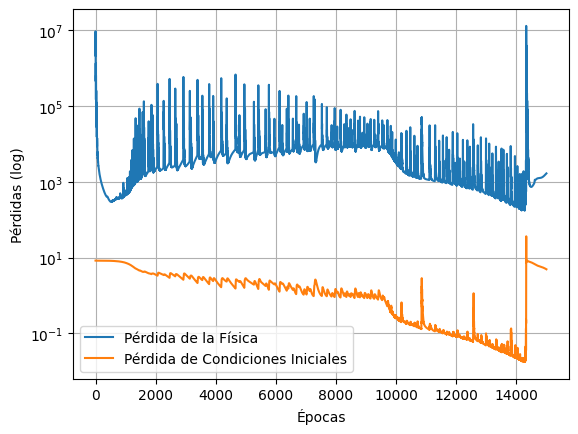

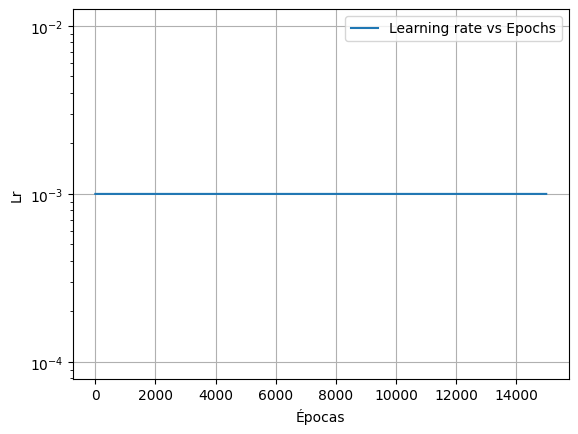


================ REPORTE DE ERROR MAE (ω = 5.50π) ================
Piso 1 -> MAE: 5.934536e-02 m
Piso 2 -> MAE: 1.118388e-01 m
Piso 3 -> MAE: 1.409867e-01 m
Piso 4 -> MAE: 1.393373e-01 m
----------------------------------------------------------------
MAE GLOBAL DEL EDIFICIO: 1.128770e-01 m

Piso 1: MAE = 5.934536e-02 m


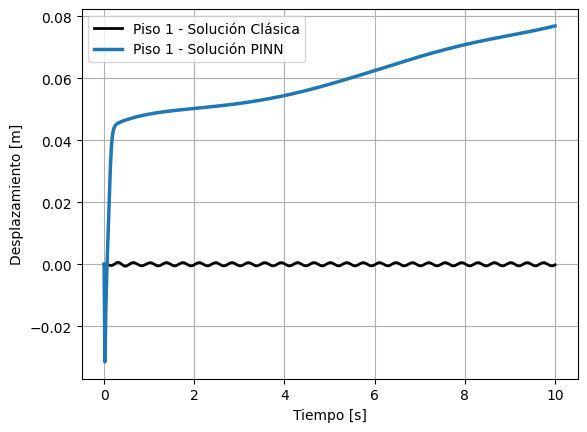

Piso 2: MAE = 1.118388e-01 m


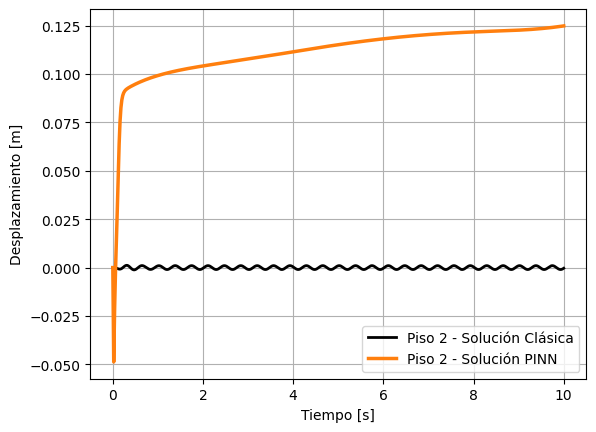

Piso 3: MAE = 1.409867e-01 m


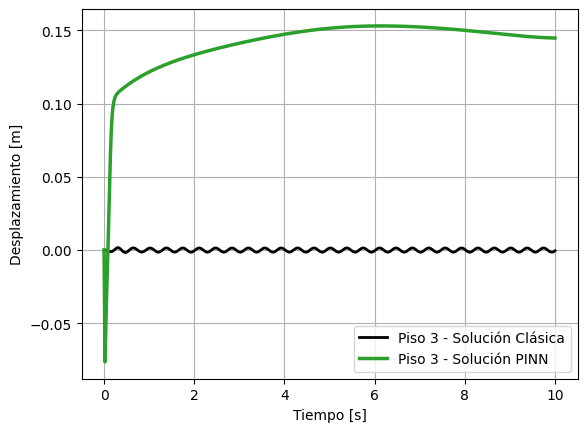

Piso 4: MAE = 1.393373e-01 m


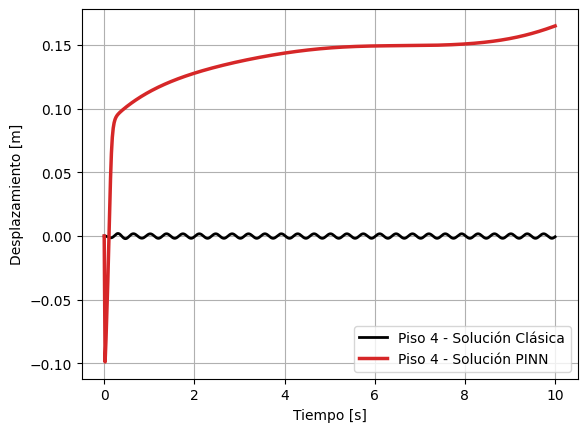

MAE Global: 1.128770e-01 m


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from scipy.integrate import solve_ivp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# 2. ARQUITECTURA VANILLA CON ENTRADA EXPANDIDA
class AutoregressivePINN(nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_in, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, dim_out) # Salidas: [u1, u2, u3, u4]
        )
    def forward(self, x):
        return self.net(x)



def generar_matriz_K_torch(N_dof, k_val, device='cpu'):
    """
    Genera la matriz de rigidez K acoplada para un edificio de N pisos en PyTorch.
    """
    # 1. Inicializar una matriz de ceros con el tamaño adecuado
    K = torch.zeros((N_dof, N_dof), dtype=torch.float32, device=device)

    # 2. Llenar la estructura tridiagonal para los pisos intermedios
    for i in range(N_dof - 1):
        K[i, i] = 2 * k_val      # Conectado con el piso de abajo y el de arriba
        K[i, i+1] = -k_val     # Acoplamiento con el piso superior
        K[i+1, i] = -k_val     # Acoplamiento simétrico

    # 3. Ajustar la condición de borde del techo (último piso)
    # El techo no tiene un piso arriba, por lo que su rigidez propia es solo k
    K[N_dof - 1, N_dof - 1] = k_val

    return K

# Ejemplo de uso para 5 pisos:
# K_pinn = generar_matriz_K_torch(N_dof=5, k_val=400.0, device=device)

def Generar_Contexto_Operacional(N_dof, t_step_max, rango_omega, m_val=1, k_val=400, num_muestras=5000, tiempo_global=10):
    dim_entrada = 3 + 2 * N_dof  # 10 para N_dof = 4, añadimos "tiempo global" ->11

    m_vec = torch.tensor([m_val]*N_dof, device="cpu")  #masas del sistema

    K_torch = generar_matriz_K_torch(N_dof=N_dof, k_val=k_val)

    C_torch = 0.05 * torch.diag(m_vec) + 0.01 * K_torch



    sobol = torch.quasirandom.SobolEngine(dim_entrada)
    X_raw = sobol.draw(num_muestras).to(device) # saca numeros randoms de 0 a 1

    # Escalamiento del hipercubo de estados de 5k filas, con columnas:| tiempo | omega | u_0 1 | u_0 2 | u_0 3 | u_0 4 | v_0 1 | v_0 2 | v_0 3 | v_0 4 |
    X_f = torch.zeros(num_muestras, dim_entrada, device="cpu")
    X_f[:, 0:1] = X_raw[:, 0:1] * tiempo_global
    X_f[:, 1:2] = X_raw[:, 1:2] * t_step_max
    X_f[:, 2:3] = X_raw[:, 2:3] * (rango_omega[1]*np.pi - rango_omega[0]*np.pi) + rango_omega[0]*np.pi # omega
    X_f[:, 3:3+N_dof] = (X_raw[:, 3:3+N_dof] - 0.5) * 0.2            # u0 en [-1, 1] m
    X_f[:, 3+N_dof:] = (X_raw[:, 3+N_dof:] - 0.5) * 10              # v0 en [-5, 5] m/s
    X_f.requires_grad_(True)

    return (m_vec, K_torch, C_torch, X_f)


def Entrenar_Red(N_dof, t_step_max, M_vec, K, C, X_f, epochs, lam_amortiguamiento=1, learning_rate=1e-2):
    print(f"Utilizando: {device}")
    m_vec = M_vec.to(device)
    K_torch = K.to(device)
    C_torch = C.to(device)
    X_f = X_f.to(device)

    dim_entrada = 3 + 2 * N_dof  # 10 para N_dof = 4
    model = AutoregressivePINN(dim_entrada, N_dof).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor= 0.5, patience=80)



    Loss_f_list = []
    Loss_ic_list = []
    LR_list=[]
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        # Extraer variables del tensor para cálculos físicos
        t_abs = X_f[:, 0:1]
        t = X_f[:, 1:2]
        omega = X_f[:, 2:3]
        u0_input = X_f[:, 3:3+N_dof]
        v0_input = X_f[:, 3+N_dof:]

        # Predicción de la red
        u_f = model(X_f)

        # Cálculo de derivadas temporales continuas
        u_t_list, u_tt_list = [], []
        for i in range(N_dof):
            g_u = torch.autograd.grad(u_f[:, i], X_f, torch.ones_like(u_f[:, i]), create_graph=True)[0]
            u_t_i = g_u[:, 1:2] # derivada respecto a t (columna 0)
            u_t_list.append(u_t_i)
            u_tt_list.append(torch.autograd.grad(u_t_i, X_f, torch.ones_like(u_t_i), create_graph=True)[0][:, 1:2])

        u_t = torch.cat(u_t_list, dim=1)
        u_tt = torch.cat(u_tt_list, dim=1)

        # --- PÉRDIDA DE LA FÍSICA ---
        F = torch.zeros_like(u_f)
        t_current = t_abs + t
        F[:, -1:] = -100.0 * torch.sin(omega * t_current)
        residual = u_tt + lam_amortiguamiento*u_t @ (C_torch/m_val).T + u_f @ (K_torch/m_val).T - F/m_val #Añadimos el factor de relevancia de amortiguamiento para incitar su relevancia
        loss_f = torch.mean(residual**2)

        # --- PÉRDIDA DE CONDICIONES INICIALES (Evaluadas dinámicamente en t=0) ---
        # Creamos un clon exacto de X_f pero forzando t = 0
        X_ic = X_f.clone()
        X_ic[:, 1:2] = 0.0

        u_pred_0 = model(X_ic)

        u_t_0_list = []
        for i in range(N_dof):
            g_u0 = torch.autograd.grad(u_pred_0[:, i], X_ic, torch.ones_like(u_pred_0[:, i]), create_graph=True)[0]
            u_t_0_list.append(g_u0[:, 1:2])
        u_t_0 = torch.cat(u_t_0_list, dim=1)

        # Forzamos a que la salida en t=0 sea igual al u0 y v0 pasados en el input
        loss_ic = torch.mean((u_pred_0 - u0_input)**2) + torch.mean((u_t_0 - v0_input)**2)

        Loss_f_list.append(loss_f.item())
        Loss_ic_list.append(loss_ic.item())

        # Pérdida Total
        lam_ic = 10000.0
        loss_total = 1.0 * loss_f + lam_ic * loss_ic
        current_lr = optimizer.param_groups[0]['lr']
        LR_list.append(current_lr)

        loss_total.backward()
        optimizer.step()
        # scheduler.step(loss_total)

        if epoch % 2000 == 0 or epoch == 1:
            print(f"Época {epoch}/{epochs} | Loss Total: {loss_total.item():.6e} | Loss_f: {loss_f.item():.6e} | Loss_ic: {lam_ic*loss_ic.item():.6e} | Lr: {current_lr:.6e}")

    plt.plot(Loss_f_list, label='Pérdida de la Física')
    plt.plot(Loss_ic_list, label='Pérdida de Condiciones Iniciales')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Pérdidas (log)')
    plt.yscale("log")
    plt.grid()
    plt.savefig(RUTA_PLOTS + "Tanh_noScheduler_Loss.png", dpi=400, bbox_inches="tight")
    plt.show()

    plt.plot(LR_list, label='Learning rate vs Epochs')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Lr')
    plt.yscale("log")
    plt.grid()
    plt.savefig(RUTA_PLOTS + "Tanh_noScheduler_Lr.png", dpi=400, bbox_inches="tight")
    plt.show()
    return(model)



def evaluar_y_cuantificar_pinn(model, N_dof, omega_test, m_val, k_val, tiempo_total=2.0, t_step_max=0.1):
    """
    Evalúa la PINN Autoregresiva en un horizonte largo mediante rolling inference,
    la compara con SciPy (RK45) y calcula el MAE (Mean Absolute Error).

    Argumentos:
    - model: Tu modelo PINN entrenado.
    - N_dof: Número de grados de libertad (pisos).
    - omega_test: Frecuencia paramétrica a evaluar (ej: 5.5 * np.pi).
    - tiempo_total: Tiempo total de la simulación extensa (por defecto 2.0s).
    - t_step_max: El paso delta_t con el que se entrenó la red (por defecto 0.1s).
    """
    # Verificar dispositivo del modelo
    device = next(model.parameters()).device
    model.eval()

    # 1. GENERACIÓN INTERNA DE MATRICES FÍSICAS (Basado en N_dof)


    M_np = np.diag([m_val] * N_dof)
    K_np = generar_matriz_K_torch(N_dof, k_val).numpy()
    C_np = 0.05 * M_np + 0.01 * K_np
    M_inv = np.linalg.inv(M_np)
    # 2. SIMULACIÓN TEMPORAL ENCADENADA (PINN ROLLING INFERENCE)
    pasos_totales = int(tiempo_total / t_step_max)

    historial_tiempo = [0.0]
    historial_desplazamientos = [np.zeros(N_dof)]

    u_actual = torch.zeros(1, N_dof, device=device)
    v_actual = torch.zeros(1, N_dof, device=device)
    t_delta_tensor = torch.tensor([[t_step_max]], device=device)
    omega_tensor = torch.tensor([[omega_test]], device=device)

    t_acumulado = 0.0

    for paso in range(pasos_totales):
        t_abs_tensor = torch.tensor([[t_acumulado]], device=device)

        # Concatena las 11 dimensiones en el orden exacto del entrenamiento:
        # [t_abs (1), t_rel (1), omega (1), u0 (4), v0 (4)] = 11 dimensiones
        X_step = torch.cat([t_abs_tensor, t_delta_tensor, omega_tensor, u_actual, v_actual], dim=1)
        X_step.requires_grad_(True)

        u_siguiente = model(X_step)

        # Bucle de velocidad con la corrección de retención de grafo
        v_siguiente_list = []
        for i in range(N_dof):
            g_u = torch.autograd.grad(
                u_siguiente[:, i],
                X_step,
                torch.ones_like(u_siguiente[:, i]),
                retain_graph=True
            )[0]
            v_siguiente_list.append(g_u[:, 1:2])
        v_siguiente = torch.cat(v_siguiente_list, dim=1)

        # Actualizar estados para el siguiente paso
        u_actual = u_siguiente.detach()
        v_actual = v_siguiente.detach()

        t_acumulado += t_step_max
        historial_tiempo.append(t_acumulado)
        historial_desplazamientos.append(u_actual.cpu().numpy()[0])

    u_pinn = np.array(historial_desplazamientos).T # Dimensión: (N_dof, pasos + 1)
    t_eval_pinn = np.array(historial_tiempo)

    # 3. SOLVER CLÁSICO (SciPy RK45) EVALUADO EN LOS MISMOS PUNTOS EXACTOS
    def sistema_NDOF(t, y):
        u = y[:N_dof]
        v = y[N_dof:]
        F = np.zeros(N_dof)
        F[-1] = -100.0 * np.sin(omega_test * t) # Fuerza en el techo
        dudt = v
        dvdt = M_inv @ (F - C_np @ v - K_np @ u)
        return np.concatenate([dudt, dvdt])

    y0 = np.zeros(2 * N_dof)
    solucion_exacta = solve_ivp(
        sistema_NDOF,
        (0.0, tiempo_total),
        y0,
        t_eval=t_eval_pinn, # Forzamos alineación temporal perfecta para restar matrices
        method='RK45'
    )
    u_clasico = solucion_exacta.y[:N_dof] # Dimensión: (N_dof, pasos + 1)

    # 4. CÁLCULO CUANTITATIVO DEL MAE (Mean Absolute Error)
    print(f"\n================ REPORTE DE ERROR MAE (ω = {omega_test/np.pi:.2f}π) ================")
    maes_por_piso = []

    for i in range(N_dof):
        # MAE = Mean(| u_real - u_pred |)
        mae_piso = np.mean(np.abs(u_clasico[i] - u_pinn[i]))
        maes_por_piso.append(mae_piso)
        print(f"Piso {i+1} -> MAE: {mae_piso:.6e} m")

    mae_global = np.mean(np.abs(u_clasico - u_pinn))
    print(f"----------------------------------------------------------------")
    print(f"MAE GLOBAL DEL EDIFICIO: {mae_global:.6e} m")
    print("================================================================\n")

    # Retorna los tiempos, la solución clásica, la solución pinn y el diccionario de métricas
    return t_eval_pinn, u_clasico, u_pinn, {"maes_pisos": maes_por_piso, "mae_global": mae_global}

print(f"MODELO CLÁSICO TANH")


n_dof = 4
rango_omega = (3 * np.pi, 7 * np.pi)    #Parámetro operacional variable
m_val, k_val = 80.0, 400000.0             # 80 tons y 40.000 kN/m^2
t_step_max = 0.02          #1/5 de la frecuencia de oscilación estimada
condiciones = Generar_Contexto_Operacional(n_dof, t_step_max, rango_omega, m_val, k_val)
model = Entrenar_Red(n_dof, t_step_max, *condiciones, epochs=15000, lam_amortiguamiento=1, learning_rate=1e-3)

time, u_clasico, u_pinn, metrics = evaluar_y_cuantificar_pinn(model, n_dof, omega_test=5.5 * np.pi, m_val=m_val, k_val=k_val, tiempo_total=10, t_step_max=t_step_max)

for piso, mae in enumerate(metrics["maes_pisos"]):
    print(f"Piso {piso+1}: MAE = {mae:.6e} m")
    plt.plot(time, u_clasico[piso], label=f'Piso {piso+1} - Solución Clásica', color='black', linewidth=2)
    plt.plot(time, u_pinn[piso], label=f'Piso {piso+1} - Solución PINN', color=f'C{piso}', linewidth=2.5)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Desplazamiento [m]')
    plt.grid()
    plt.legend()
    plt.savefig(RUTA_PLOTS + f"Tanh_noScheduler_piso{piso+1}.png", dpi=400, bbox_inches="tight")
    plt.show()
print(f"MAE Global: {metrics['mae_global']:.6e} m")

MODELO CLÁSICO TANH
Utilizando: cuda
Época 1/15000 | Loss Total: 3.075416e+05 | Loss_f: 2.240169e+05 | Loss_ic: 8.352477e+04 | Lr: 1.000000e-03
Época 2000/15000 | Loss Total: 3.568522e+04 | Loss_f: 2.552425e+03 | Loss_ic: 3.313279e+04 | Lr: 1.000000e-03
Época 4000/15000 | Loss Total: 2.081403e+04 | Loss_f: 9.425862e+03 | Loss_ic: 1.138817e+04 | Lr: 2.500000e-04
Época 6000/15000 | Loss Total: 2.117275e+04 | Loss_f: 1.180552e+04 | Loss_ic: 9.367238e+03 | Lr: 1.250000e-04
Época 8000/15000 | Loss Total: 2.229217e+04 | Loss_f: 1.356335e+04 | Loss_ic: 8.728824e+03 | Lr: 1.250000e-04
Época 10000/15000 | Loss Total: 1.863902e+04 | Loss_f: 1.025883e+04 | Loss_ic: 8.380194e+03 | Lr: 1.250000e-04
Época 12000/15000 | Loss Total: 1.828413e+04 | Loss_f: 1.037988e+04 | Loss_ic: 7.904257e+03 | Lr: 6.250000e-05
Época 14000/15000 | Loss Total: 1.794879e+04 | Loss_f: 1.030419e+04 | Loss_ic: 7.644608e+03 | Lr: 6.250000e-05


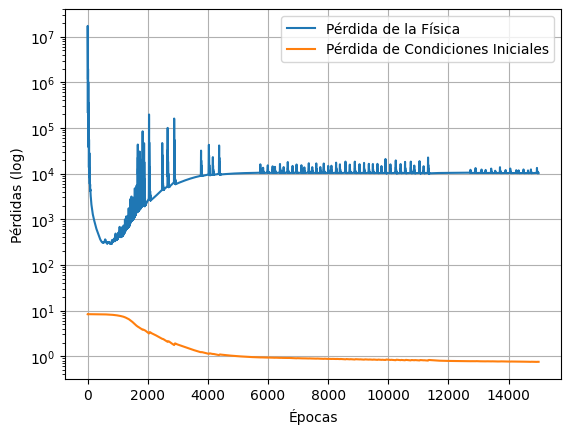

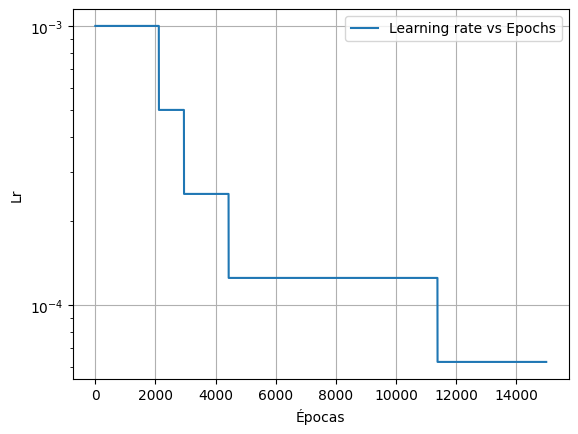


================ REPORTE DE ERROR MAE (ω = 5.50π) ================
Piso 1 -> MAE: 4.301749e-02 m
Piso 2 -> MAE: 3.251978e-02 m
Piso 3 -> MAE: 5.933546e-02 m
Piso 4 -> MAE: 5.972987e-02 m
----------------------------------------------------------------
MAE GLOBAL DEL EDIFICIO: 4.865065e-02 m

Piso 1: MAE = 4.301749e-02 m


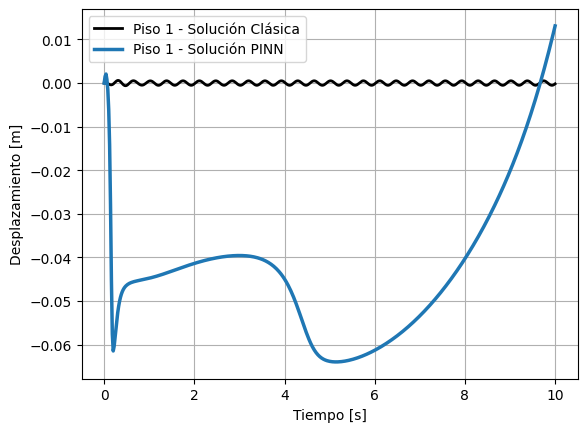

Piso 2: MAE = 3.251978e-02 m


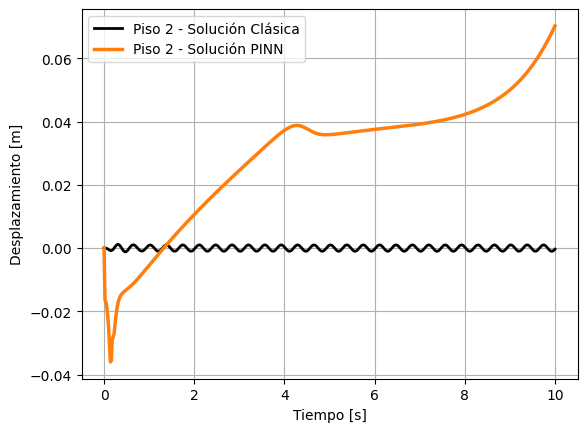

Piso 3: MAE = 5.933546e-02 m


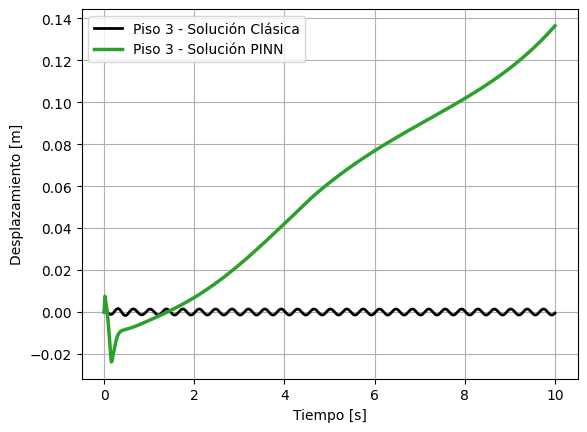

Piso 4: MAE = 5.972987e-02 m


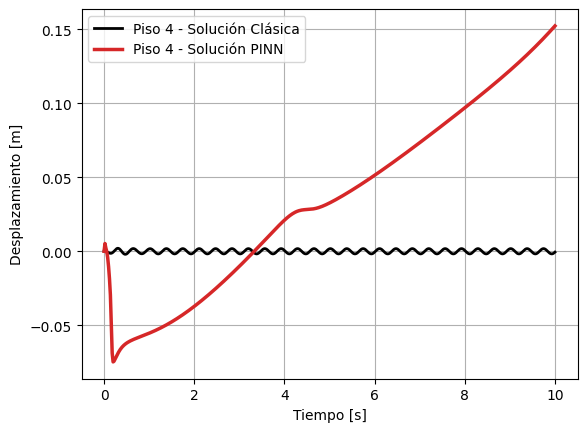

MAE Global: 4.865065e-02 m


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from scipy.integrate import solve_ivp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# 2. ARQUITECTURA VANILLA CON ENTRADA EXPANDIDA
class AutoregressivePINN(nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_in, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, dim_out) # Salidas: [u1, u2, u3, u4]
        )
    def forward(self, x):
        return self.net(x)



def generar_matriz_K_torch(N_dof, k_val, device='cpu'):
    """
    Genera la matriz de rigidez K acoplada para un edificio de N pisos en PyTorch.
    """
    # 1. Inicializar una matriz de ceros con el tamaño adecuado
    K = torch.zeros((N_dof, N_dof), dtype=torch.float32, device=device)

    # 2. Llenar la estructura tridiagonal para los pisos intermedios
    for i in range(N_dof - 1):
        K[i, i] = 2 * k_val      # Conectado con el piso de abajo y el de arriba
        K[i, i+1] = -k_val     # Acoplamiento con el piso superior
        K[i+1, i] = -k_val     # Acoplamiento simétrico

    # 3. Ajustar la condición de borde del techo (último piso)
    # El techo no tiene un piso arriba, por lo que su rigidez propia es solo k
    K[N_dof - 1, N_dof - 1] = k_val

    return K

# Ejemplo de uso para 5 pisos:
# K_pinn = generar_matriz_K_torch(N_dof=5, k_val=400.0, device=device)

def Generar_Contexto_Operacional(N_dof, t_step_max, rango_omega, m_val=1, k_val=400, num_muestras=5000, tiempo_global=10):
    dim_entrada = 3 + 2 * N_dof  # 10 para N_dof = 4, añadimos "tiempo global" ->11

    m_vec = torch.tensor([m_val]*N_dof, device="cpu")  #masas del sistema

    K_torch = generar_matriz_K_torch(N_dof=N_dof, k_val=k_val)

    C_torch = 0.05 * torch.diag(m_vec) + 0.01 * K_torch



    sobol = torch.quasirandom.SobolEngine(dim_entrada)
    X_raw = sobol.draw(num_muestras).to(device) # saca numeros randoms de 0 a 1

    # Escalamiento del hipercubo de estados de 5k filas, con columnas:| tiempo | omega | u_0 1 | u_0 2 | u_0 3 | u_0 4 | v_0 1 | v_0 2 | v_0 3 | v_0 4 |
    X_f = torch.zeros(num_muestras, dim_entrada, device="cpu")
    X_f[:, 0:1] = X_raw[:, 0:1] * tiempo_global
    X_f[:, 1:2] = X_raw[:, 1:2] * t_step_max
    X_f[:, 2:3] = X_raw[:, 2:3] * (rango_omega[1]*np.pi - rango_omega[0]*np.pi) + rango_omega[0]*np.pi # omega
    X_f[:, 3:3+N_dof] = (X_raw[:, 3:3+N_dof] - 0.5) * 0.2            # u0 en [-1, 1] m
    X_f[:, 3+N_dof:] = (X_raw[:, 3+N_dof:] - 0.5) * 10              # v0 en [-5, 5] m/s
    X_f.requires_grad_(True)

    return (m_vec, K_torch, C_torch, X_f)


def Entrenar_Red(N_dof, t_step_max, M_vec, K, C, X_f, epochs, lam_amortiguamiento=1, learning_rate=1e-2):
    print(f"Utilizando: {device}")
    m_vec = M_vec.to(device)
    K_torch = K.to(device)
    C_torch = C.to(device)
    X_f = X_f.to(device)

    dim_entrada = 3 + 2 * N_dof  # 10 para N_dof = 4
    model = AutoregressivePINN(dim_entrada, N_dof).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor= 0.5, patience=80)



    Loss_f_list = []
    Loss_ic_list = []
    LR_list=[]
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        # Extraer variables del tensor para cálculos físicos
        t_abs = X_f[:, 0:1]
        t = X_f[:, 1:2]
        omega = X_f[:, 2:3]
        u0_input = X_f[:, 3:3+N_dof]
        v0_input = X_f[:, 3+N_dof:]

        # Predicción de la red
        u_f = model(X_f)

        # Cálculo de derivadas temporales continuas
        u_t_list, u_tt_list = [], []
        for i in range(N_dof):
            g_u = torch.autograd.grad(u_f[:, i], X_f, torch.ones_like(u_f[:, i]), create_graph=True)[0]
            u_t_i = g_u[:, 1:2] # derivada respecto a t (columna 0)
            u_t_list.append(u_t_i)
            u_tt_list.append(torch.autograd.grad(u_t_i, X_f, torch.ones_like(u_t_i), create_graph=True)[0][:, 1:2])

        u_t = torch.cat(u_t_list, dim=1)
        u_tt = torch.cat(u_tt_list, dim=1)

        # --- PÉRDIDA DE LA FÍSICA ---
        F = torch.zeros_like(u_f)
        t_current = t_abs + t
        F[:, -1:] = -100.0 * torch.sin(omega * t_current)
        residual = u_tt + lam_amortiguamiento*u_t @ (C_torch/m_val).T + u_f @ (K_torch/m_val).T - F/m_val #Añadimos el factor de relevancia de amortiguamiento para incitar su relevancia
        loss_f = torch.mean(residual**2)

        # --- PÉRDIDA DE CONDICIONES INICIALES (Evaluadas dinámicamente en t=0) ---
        # Creamos un clon exacto de X_f pero forzando t = 0
        X_ic = X_f.clone()
        X_ic[:, 1:2] = 0.0

        u_pred_0 = model(X_ic)

        u_t_0_list = []
        for i in range(N_dof):
            g_u0 = torch.autograd.grad(u_pred_0[:, i], X_ic, torch.ones_like(u_pred_0[:, i]), create_graph=True)[0]
            u_t_0_list.append(g_u0[:, 1:2])
        u_t_0 = torch.cat(u_t_0_list, dim=1)

        # Forzamos a que la salida en t=0 sea igual al u0 y v0 pasados en el input
        loss_ic = torch.mean((u_pred_0 - u0_input)**2) + torch.mean((u_t_0 - v0_input)**2)

        Loss_f_list.append(loss_f.item())
        Loss_ic_list.append(loss_ic.item())

        # Pérdida Total
        lam_ic = 10000.0
        loss_total = 1.0 * loss_f + lam_ic * loss_ic
        current_lr = optimizer.param_groups[0]['lr']
        LR_list.append(current_lr)

        loss_total.backward()
        optimizer.step()
        scheduler.step(loss_total)

        if epoch % 2000 == 0 or epoch == 1:
            print(f"Época {epoch}/{epochs} | Loss Total: {loss_total.item():.6e} | Loss_f: {loss_f.item():.6e} | Loss_ic: {lam_ic*loss_ic.item():.6e} | Lr: {current_lr:.6e}")

    plt.plot(Loss_f_list, label='Pérdida de la Física')
    plt.plot(Loss_ic_list, label='Pérdida de Condiciones Iniciales')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Pérdidas (log)')
    plt.yscale("log")
    plt.grid()
    plt.savefig(RUTA_PLOTS + "Tanh_Loss.png", dpi=400, bbox_inches="tight")
    plt.show()

    plt.plot(LR_list, label='Learning rate vs Epochs')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Lr')
    plt.yscale("log")
    plt.grid()
    plt.savefig(RUTA_PLOTS + "Tanh_Lr.png", dpi=400, bbox_inches="tight")
    plt.show()
    return(model)



def evaluar_y_cuantificar_pinn(model, N_dof, omega_test, m_val, k_val, tiempo_total=2.0, t_step_max=0.1):
    """
    Evalúa la PINN Autoregresiva en un horizonte largo mediante rolling inference,
    la compara con SciPy (RK45) y calcula el MAE (Mean Absolute Error).

    Argumentos:
    - model: Tu modelo PINN entrenado.
    - N_dof: Número de grados de libertad (pisos).
    - omega_test: Frecuencia paramétrica a evaluar (ej: 5.5 * np.pi).
    - tiempo_total: Tiempo total de la simulación extensa (por defecto 2.0s).
    - t_step_max: El paso delta_t con el que se entrenó la red (por defecto 0.1s).
    """
    # Verificar dispositivo del modelo
    device = next(model.parameters()).device
    model.eval()

    # 1. GENERACIÓN INTERNA DE MATRICES FÍSICAS (Basado en N_dof)


    M_np = np.diag([m_val] * N_dof)
    K_np = generar_matriz_K_torch(N_dof, k_val).numpy()
    C_np = 0.05 * M_np + 0.01 * K_np
    M_inv = np.linalg.inv(M_np)
    # 2. SIMULACIÓN TEMPORAL ENCADENADA (PINN ROLLING INFERENCE)
    pasos_totales = int(tiempo_total / t_step_max)

    historial_tiempo = [0.0]
    historial_desplazamientos = [np.zeros(N_dof)]

    u_actual = torch.zeros(1, N_dof, device=device)
    v_actual = torch.zeros(1, N_dof, device=device)
    t_delta_tensor = torch.tensor([[t_step_max]], device=device)
    omega_tensor = torch.tensor([[omega_test]], device=device)

    t_acumulado = 0.0

    for paso in range(pasos_totales):
        t_abs_tensor = torch.tensor([[t_acumulado]], device=device)

        # Concatena las 11 dimensiones en el orden exacto del entrenamiento:
        # [t_abs (1), t_rel (1), omega (1), u0 (4), v0 (4)] = 11 dimensiones
        X_step = torch.cat([t_abs_tensor, t_delta_tensor, omega_tensor, u_actual, v_actual], dim=1)
        X_step.requires_grad_(True)

        u_siguiente = model(X_step)

        # Bucle de velocidad con la corrección de retención de grafo
        v_siguiente_list = []
        for i in range(N_dof):
            g_u = torch.autograd.grad(
                u_siguiente[:, i],
                X_step,
                torch.ones_like(u_siguiente[:, i]),
                retain_graph=True
            )[0]
            v_siguiente_list.append(g_u[:, 1:2])
        v_siguiente = torch.cat(v_siguiente_list, dim=1)

        # Actualizar estados para el siguiente paso
        u_actual = u_siguiente.detach()
        v_actual = v_siguiente.detach()

        t_acumulado += t_step_max
        historial_tiempo.append(t_acumulado)
        historial_desplazamientos.append(u_actual.cpu().numpy()[0])

    u_pinn = np.array(historial_desplazamientos).T # Dimensión: (N_dof, pasos + 1)
    t_eval_pinn = np.array(historial_tiempo)

    # 3. SOLVER CLÁSICO (SciPy RK45) EVALUADO EN LOS MISMOS PUNTOS EXACTOS
    def sistema_NDOF(t, y):
        u = y[:N_dof]
        v = y[N_dof:]
        F = np.zeros(N_dof)
        F[-1] = -100.0 * np.sin(omega_test * t) # Fuerza en el techo
        dudt = v
        dvdt = M_inv @ (F - C_np @ v - K_np @ u)
        return np.concatenate([dudt, dvdt])

    y0 = np.zeros(2 * N_dof)
    solucion_exacta = solve_ivp(
        sistema_NDOF,
        (0.0, tiempo_total),
        y0,
        t_eval=t_eval_pinn, # Forzamos alineación temporal perfecta para restar matrices
        method='RK45'
    )
    u_clasico = solucion_exacta.y[:N_dof] # Dimensión: (N_dof, pasos + 1)

    # 4. CÁLCULO CUANTITATIVO DEL MAE (Mean Absolute Error)
    print(f"\n================ REPORTE DE ERROR MAE (ω = {omega_test/np.pi:.2f}π) ================")
    maes_por_piso = []

    for i in range(N_dof):
        # MAE = Mean(| u_real - u_pred |)
        mae_piso = np.mean(np.abs(u_clasico[i] - u_pinn[i]))
        maes_por_piso.append(mae_piso)
        print(f"Piso {i+1} -> MAE: {mae_piso:.6e} m")

    mae_global = np.mean(np.abs(u_clasico - u_pinn))
    print(f"----------------------------------------------------------------")
    print(f"MAE GLOBAL DEL EDIFICIO: {mae_global:.6e} m")
    print("================================================================\n")

    # Retorna los tiempos, la solución clásica, la solución pinn y el diccionario de métricas
    return t_eval_pinn, u_clasico, u_pinn, {"maes_pisos": maes_por_piso, "mae_global": mae_global}

print(f"MODELO CLÁSICO TANH")


n_dof = 4
rango_omega = (3 * np.pi, 7 * np.pi)    #Parámetro operacional variable
m_val, k_val = 80.0, 400000.0             # 80 tons y 40.000 kN/m^2
t_step_max = 0.02          #1/5 de la frecuencia de oscilación estimada
condiciones = Generar_Contexto_Operacional(n_dof, t_step_max, rango_omega, m_val, k_val)
model = Entrenar_Red(n_dof, t_step_max, *condiciones, epochs=15000, lam_amortiguamiento=1, learning_rate=1e-3)

time, u_clasico, u_pinn, metrics = evaluar_y_cuantificar_pinn(model, n_dof, omega_test=5.5 * np.pi, m_val=m_val, k_val=k_val, tiempo_total=10, t_step_max=t_step_max)

for piso, mae in enumerate(metrics["maes_pisos"]):
    print(f"Piso {piso+1}: MAE = {mae:.6e} m")
    plt.plot(time, u_clasico[piso], label=f'Piso {piso+1} - Solución Clásica', color='black', linewidth=2)
    plt.plot(time, u_pinn[piso], label=f'Piso {piso+1} - Solución PINN', color=f'C{piso}', linewidth=2.5)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Desplazamiento [m]')
    plt.grid()
    plt.legend()
    plt.savefig(RUTA_PLOTS + f"Tanh_piso{piso+1}.png", dpi=400, bbox_inches="tight")
    plt.show()
print(f"MAE Global: {metrics['mae_global']:.6e} m")

# Modelo Fourier Encoding

MODELO FOURIER ENCODING
Utilizando: cuda
Época 1/15000 | Loss Total: 2.115604e+06 | Loss_f: 1.700788e+06 | Loss_ic: 4.148155e+05 | Lr: 1.000000e-03
Época 2000/15000 | Loss Total: 4.745654e+04 | Loss_f: 9.758009e+03 | Loss_ic: 3.769853e+04 | Lr: 1.000000e-03
Época 4000/15000 | Loss Total: 1.436386e+04 | Loss_f: 3.303374e+03 | Loss_ic: 1.106049e+04 | Lr: 1.000000e-03
Época 6000/15000 | Loss Total: 9.389061e+03 | Loss_f: 3.328159e+03 | Loss_ic: 6.060901e+03 | Lr: 5.000000e-04
Época 8000/15000 | Loss Total: 4.685949e+03 | Loss_f: 6.489276e+02 | Loss_ic: 4.037021e+03 | Lr: 2.500000e-04
Época 10000/15000 | Loss Total: 3.344473e+03 | Loss_f: 4.555723e+02 | Loss_ic: 2.888901e+03 | Lr: 2.500000e-04
Época 12000/15000 | Loss Total: 2.634458e+03 | Loss_f: 3.199066e+02 | Loss_ic: 2.314552e+03 | Lr: 1.250000e-04
Época 14000/15000 | Loss Total: 2.108070e+03 | Loss_f: 2.624807e+02 | Loss_ic: 1.845589e+03 | Lr: 1.250000e-04


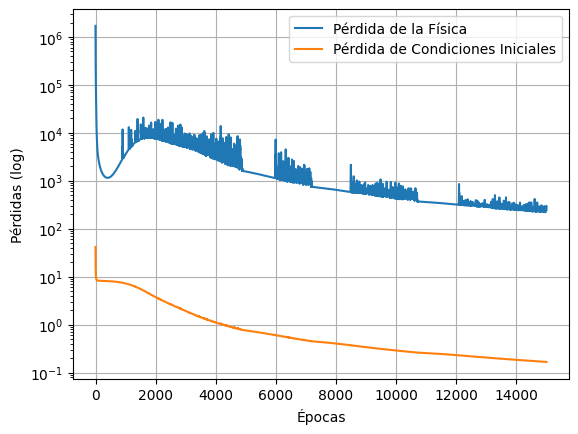

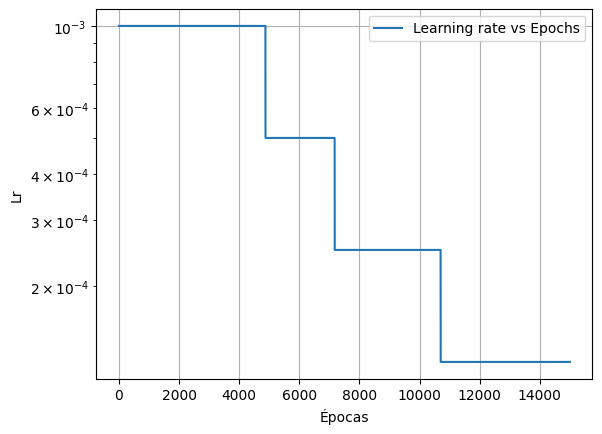


================ REPORTE DE ERROR MAE (ω = 5.50π) ================
Piso 1 -> MAE: 2.369526e-02 m
Piso 2 -> MAE: 2.906699e-02 m
Piso 3 -> MAE: 3.528240e-02 m
Piso 4 -> MAE: 4.095877e-02 m
----------------------------------------------------------------
MAE GLOBAL DEL EDIFICIO: 3.225085e-02 m

Piso 1: MAE = 2.369526e-02 m


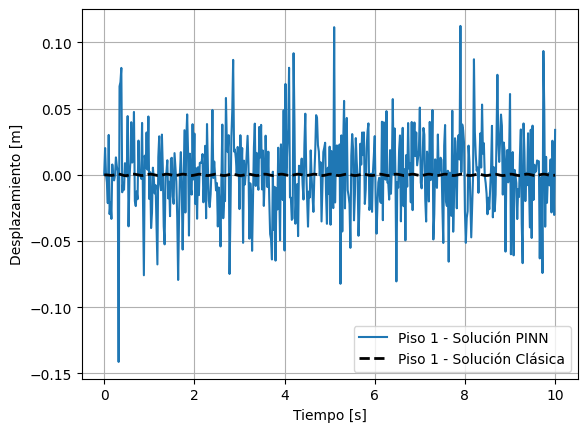

Piso 2: MAE = 2.906699e-02 m


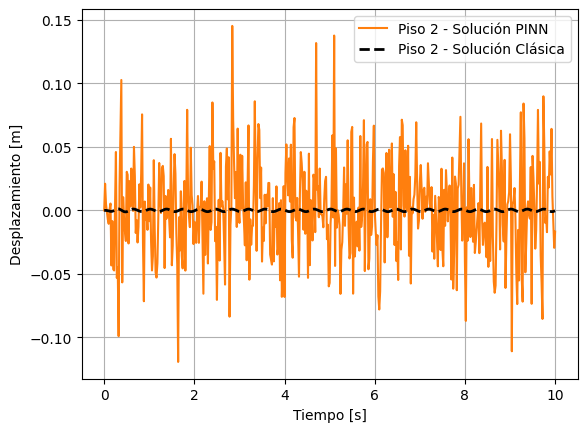

Piso 3: MAE = 3.528240e-02 m


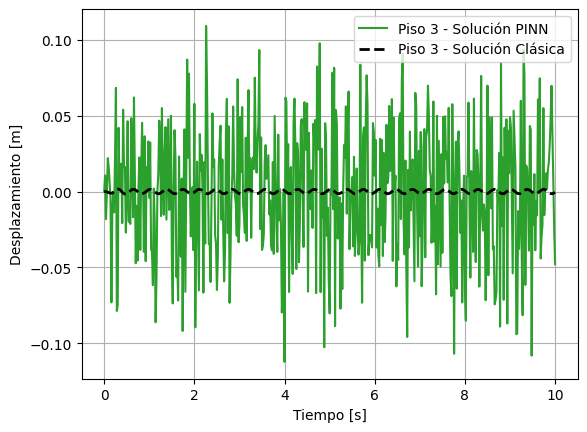

Piso 4: MAE = 4.095877e-02 m


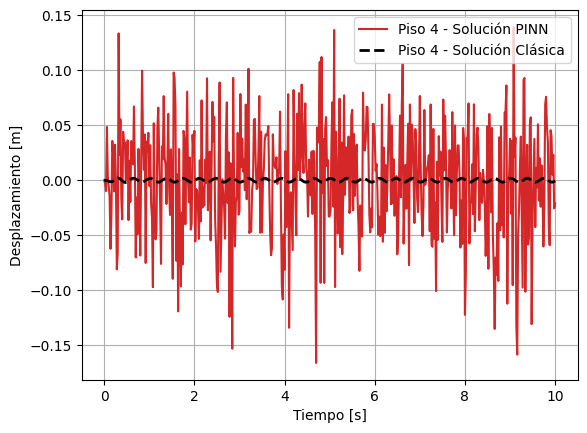

MAE Global: 3.225085e-02 m


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from scipy.integrate import solve_ivp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



class FourierFeatures(nn.Module):
    def __init__(self, dim_in, num_features, sigma=15.0):
        super().__init__()
        # Se genera una matriz de frecuencias aleatorias fija (no entrenable) con frecuencias sampleadas de una gaussiana con sigma
        self.B = nn.Parameter(torch.randn(dim_in, num_features) * sigma, requires_grad=False)


    def forward(self, x):
        # Proyección x * B
        x_proj = 2.0 * np.pi * x @ self.B
        # Salida: [cos(2pi B x), sin(2pi B x)]
        return torch.cat([torch.cos(x_proj), torch.sin(x_proj)], dim=-1)

class AutoregressivePINN_Fourier(nn.Module):
    def __init__(self, dim_in, dim_out, num_fourier_features=32):
        super().__init__()

        # Asumiendo que las primeras 3 columnas son [t_abs, t, omega]
        self.dim_fourier_in = 3
        self.dim_condiciones_in = dim_in - 3 # u0 y v0 pasan directo

        self.fourier_layer = FourierFeatures(dim_in=self.dim_fourier_in, num_features=num_fourier_features)

        # La nueva dimensión de entrada es: 2 * num_features (por el seno y coseno) + el resto de variables
        dim_hidden_in = (2 * num_fourier_features) + self.dim_condiciones_in

        self.net = nn.Sequential(
            nn.Linear(dim_hidden_in, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, dim_out)
        )

    def forward(self, x):
        # Separar variables oscilatorias de las condiciones de estado
        x_osc = x[:, :self.dim_fourier_in]
        x_estado = x[:, self.dim_fourier_in:]

        # Aplicar Fourier solo a t_abs, t y omega
        x_osc_encoded = self.fourier_layer(x_osc)

        # Re-ensamblar el tensor de entrada
        x_encoded = torch.cat([x_osc_encoded, x_estado], dim=1)

        return self.net(x_encoded)

def generar_matriz_K_torch(N_dof, k_val, device='cpu'):
    """
    Genera la matriz de rigidez K acoplada para un edificio de N pisos en PyTorch.
    """
    # 1. Inicializar una matriz de ceros con el tamaño adecuado
    K = torch.zeros((N_dof, N_dof), dtype=torch.float32, device=device)

    # 2. Llenar la estructura tridiagonal para los pisos intermedios
    for i in range(N_dof - 1):
        K[i, i] = 2 * k_val      # Conectado con el piso de abajo y el de arriba
        K[i, i+1] = -k_val     # Acoplamiento con el piso superior
        K[i+1, i] = -k_val     # Acoplamiento simétrico

    # 3. Ajustar la condición de borde del techo (último piso)
    # El techo no tiene un piso arriba, por lo que su rigidez propia es solo k
    K[N_dof - 1, N_dof - 1] = k_val

    return K

# Ejemplo de uso para 5 pisos:
# K_pinn = generar_matriz_K_torch(N_dof=5, k_val=400.0, device=device)

def Generar_Contexto_Operacional(N_dof, t_step_max, rango_omega, m_val=1, k_val=400, num_muestras=5000, tiempo_global=10):
    dim_entrada = 3 + 2 * N_dof  # 10 para N_dof = 4, añadimos "tiempo global" ->11

    m_vec = torch.tensor([m_val]*N_dof, device="cpu")  #masas del sistema

    K_torch = generar_matriz_K_torch(N_dof=N_dof, k_val=k_val)

    C_torch = 0.05 * torch.diag(m_vec) + 0.01 * K_torch



    sobol = torch.quasirandom.SobolEngine(dim_entrada)
    X_raw = sobol.draw(num_muestras).to(device) # saca numeros randoms de 0 a 1

    # Escalamiento del hipercubo de estados de 5k filas, con columnas:| tiempo | omega | u_0 1 | u_0 2 | u_0 3 | u_0 4 | v_0 1 | v_0 2 | v_0 3 | v_0 4 |
    X_f = torch.zeros(num_muestras, dim_entrada, device="cpu")
    X_f[:, 0:1] = X_raw[:, 0:1] * tiempo_global
    X_f[:, 1:2] = X_raw[:, 1:2] * t_step_max
    X_f[:, 2:3] = X_raw[:, 2:3] * (rango_omega[1]*np.pi - rango_omega[0]*np.pi) + rango_omega[0]*np.pi # omega
    X_f[:, 3:3+N_dof] = (X_raw[:, 3:3+N_dof] - 0.5) * 0.2            # u0 en [-1, 1] m
    X_f[:, 3+N_dof:] = (X_raw[:, 3+N_dof:] - 0.5) * 10              # v0 en [-5, 5] m/s
    X_f.requires_grad_(True)

    return (m_vec, K_torch, C_torch, X_f)


def Entrenar_Red(N_dof, t_step_max, M_vec, K, C, X_f, epochs, lam_amortiguamiento=1, learning_rate=1e-2):
    print(f"Utilizando: {device}")
    m_vec = M_vec.to(device)
    K_torch = K.to(device)
    C_torch = C.to(device)
    X_f = X_f.to(device)

    dim_entrada = 3 + 2 * N_dof  # 10 para N_dof = 4
    model = AutoregressivePINN_Fourier(dim_entrada, N_dof).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor= 0.5, patience=80)



    Loss_f_list = []
    Loss_ic_list = []
    LR_list=[]
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        # Extraer variables del tensor para cálculos físicos
        t_abs = X_f[:, 0:1]
        t = X_f[:, 1:2]
        omega = X_f[:, 2:3]
        u0_input = X_f[:, 3:3+N_dof]
        v0_input = X_f[:, 3+N_dof:]

        # Predicción de la red
        u_f = model(X_f)

        # Cálculo de derivadas temporales continuas
        u_t_list, u_tt_list = [], []
        for i in range(N_dof):
            g_u = torch.autograd.grad(u_f[:, i], X_f, torch.ones_like(u_f[:, i]), create_graph=True)[0]
            u_t_i = g_u[:, 1:2] # derivada respecto a t (columna 0)
            u_t_list.append(u_t_i)
            u_tt_list.append(torch.autograd.grad(u_t_i, X_f, torch.ones_like(u_t_i), create_graph=True)[0][:, 1:2])

        u_t = torch.cat(u_t_list, dim=1)
        u_tt = torch.cat(u_tt_list, dim=1)

        # --- PÉRDIDA DE LA FÍSICA ---
        F = torch.zeros_like(u_f)
        t_current = t_abs + t
        F[:, -1:] = -100.0 * torch.sin(omega * t_current)
        residual = u_tt + lam_amortiguamiento*u_t @ (C_torch/m_val).T + u_f @ (K_torch/m_val).T - F/m_val #Añadimos el factor de relevancia de amortiguamiento para incitar su relevancia
        loss_f = torch.mean(residual**2)

        # --- PÉRDIDA DE CONDICIONES INICIALES (Evaluadas dinámicamente en t=0) ---
        # Creamos un clon exacto de X_f pero forzando t = 0
        X_ic = X_f.clone()
        X_ic[:, 1:2] = 0.0

        u_pred_0 = model(X_ic)

        u_t_0_list = []
        for i in range(N_dof):
            g_u0 = torch.autograd.grad(u_pred_0[:, i], X_ic, torch.ones_like(u_pred_0[:, i]), create_graph=True)[0]
            u_t_0_list.append(g_u0[:, 1:2])
        u_t_0 = torch.cat(u_t_0_list, dim=1)

        # Forzamos a que la salida en t=0 sea igual al u0 y v0 pasados en el input
        loss_ic = torch.mean((u_pred_0 - u0_input)**2) + torch.mean((u_t_0 - v0_input)**2)

        Loss_f_list.append(loss_f.item())
        Loss_ic_list.append(loss_ic.item())

        # Pérdida Total
        lam_ic = 10000.0
        loss_total = 1.0 * loss_f + lam_ic * loss_ic
        current_lr = optimizer.param_groups[0]['lr']
        LR_list.append(current_lr)

        loss_total.backward()
        optimizer.step()
        scheduler.step(loss_total)

        if epoch % 2000 == 0 or epoch == 1:
            print(f"Época {epoch}/{epochs} | Loss Total: {loss_total.item():.6e} | Loss_f: {loss_f.item():.6e} | Loss_ic: {lam_ic*loss_ic.item():.6e} | Lr: {current_lr:.6e}")

    plt.plot(Loss_f_list, label='Pérdida de la Física')
    plt.plot(Loss_ic_list, label='Pérdida de Condiciones Iniciales')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Pérdidas (log)')
    plt.yscale("log")
    plt.grid()
    plt.savefig(RUTA_PLOTS + "FE_Loss.png", dpi=400, bbox_inches="tight")
    plt.show()

    plt.plot(LR_list, label='Learning rate vs Epochs')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Lr')
    plt.yscale("log")
    plt.grid()
    plt.savefig(RUTA_PLOTS + "FE_Lr.png", dpi=400, bbox_inches="tight")
    plt.show()
    return(model)



def evaluar_y_cuantificar_pinn(model, N_dof, omega_test, m_val, k_val, tiempo_total=2.0, t_step_max=0.1):
    """
    Evalúa la PINN Autoregresiva en un horizonte largo mediante rolling inference,
    la compara con SciPy (RK45) y calcula el MAE (Mean Absolute Error).

    Argumentos:
    - model: Tu modelo PINN entrenado.
    - N_dof: Número de grados de libertad (pisos).
    - omega_test: Frecuencia paramétrica a evaluar (ej: 5.5 * np.pi).
    - tiempo_total: Tiempo total de la simulación extensa (por defecto 2.0s).
    - t_step_max: El paso delta_t con el que se entrenó la red (por defecto 0.1s).
    """
    # Verificar dispositivo del modelo
    device = next(model.parameters()).device
    model.eval()

    # 1. GENERACIÓN INTERNA DE MATRICES FÍSICAS (Basado en N_dof)


    M_np = np.diag([m_val] * N_dof)
    K_np = generar_matriz_K_torch(N_dof, k_val).numpy()
    C_np = 0.05 * M_np + 0.01 * K_np
    M_inv = np.linalg.inv(M_np)
    # 2. SIMULACIÓN TEMPORAL ENCADENADA (PINN ROLLING INFERENCE)
    pasos_totales = int(tiempo_total / t_step_max)

    historial_tiempo = [0.0]
    historial_desplazamientos = [np.zeros(N_dof)]

    u_actual = torch.zeros(1, N_dof, device=device)
    v_actual = torch.zeros(1, N_dof, device=device)
    t_delta_tensor = torch.tensor([[t_step_max]], device=device)
    omega_tensor = torch.tensor([[omega_test]], device=device)

    t_acumulado = 0.0

    for paso in range(pasos_totales):
        t_abs_tensor = torch.tensor([[t_acumulado]], device=device)

        # Concatena las 11 dimensiones en el orden exacto del entrenamiento:
        # [t_abs (1), t_rel (1), omega (1), u0 (4), v0 (4)] = 11 dimensiones
        X_step = torch.cat([t_abs_tensor, t_delta_tensor, omega_tensor, u_actual, v_actual], dim=1)
        X_step.requires_grad_(True)

        u_siguiente = model(X_step)

        # Bucle de velocidad con la corrección de retención de grafo
        v_siguiente_list = []
        for i in range(N_dof):
            g_u = torch.autograd.grad(
                u_siguiente[:, i],
                X_step,
                torch.ones_like(u_siguiente[:, i]),
                retain_graph=True
            )[0]
            v_siguiente_list.append(g_u[:, 1:2])
        v_siguiente = torch.cat(v_siguiente_list, dim=1)

        # Actualizar estados para el siguiente paso
        u_actual = u_siguiente.detach()
        v_actual = v_siguiente.detach()

        t_acumulado += t_step_max
        historial_tiempo.append(t_acumulado)
        historial_desplazamientos.append(u_actual.cpu().numpy()[0])

    u_pinn = np.array(historial_desplazamientos).T # Dimensión: (N_dof, pasos + 1)
    t_eval_pinn = np.array(historial_tiempo)

    # 3. SOLVER CLÁSICO (SciPy RK45) EVALUADO EN LOS MISMOS PUNTOS EXACTOS
    def sistema_NDOF(t, y):
        u = y[:N_dof]
        v = y[N_dof:]
        F = np.zeros(N_dof)
        F[-1] = -100.0 * np.sin(omega_test * t) # Fuerza en el techo
        dudt = v
        dvdt = M_inv @ (F - C_np @ v - K_np @ u)
        return np.concatenate([dudt, dvdt])

    y0 = np.zeros(2 * N_dof)
    solucion_exacta = solve_ivp(
        sistema_NDOF,
        (0.0, tiempo_total),
        y0,
        t_eval=t_eval_pinn, # Forzamos alineación temporal perfecta para restar matrices
        method='RK45'
    )
    u_clasico = solucion_exacta.y[:N_dof] # Dimensión: (N_dof, pasos + 1)

    # 4. CÁLCULO CUANTITATIVO DEL MAE (Mean Absolute Error)
    print(f"\n================ REPORTE DE ERROR MAE (ω = {omega_test/np.pi:.2f}π) ================")
    maes_por_piso = []

    for i in range(N_dof):
        # MAE = Mean(| u_real - u_pred |)
        mae_piso = np.mean(np.abs(u_clasico[i] - u_pinn[i]))
        maes_por_piso.append(mae_piso)
        print(f"Piso {i+1} -> MAE: {mae_piso:.6e} m")

    mae_global = np.mean(np.abs(u_clasico - u_pinn))
    print(f"----------------------------------------------------------------")
    print(f"MAE GLOBAL DEL EDIFICIO: {mae_global:.6e} m")
    print("================================================================\n")

    # Retorna los tiempos, la solución clásica, la solución pinn y el diccionario de métricas
    return t_eval_pinn, u_clasico, u_pinn, {"maes_pisos": maes_por_piso, "mae_global": mae_global}

print("MODELO FOURIER ENCODING")
n_dof = 4
t_step_max = 0.02
rango_omega = (3 * np.pi, 7 * np.pi)    #Parámetro operacional variable
m_val, k_val = 80.0, 400000.0             # 80 tons y 40.000 kN/m^2
condiciones = Generar_Contexto_Operacional(n_dof, t_step_max, rango_omega, m_val, k_val)
model = Entrenar_Red(n_dof, t_step_max, *condiciones, epochs=15000, lam_amortiguamiento=1, learning_rate=1e-3)

time, u_clasico, u_pinn, metrics = evaluar_y_cuantificar_pinn(model, n_dof, omega_test=5.5 * np.pi, m_val=m_val, k_val=k_val, tiempo_total=10, t_step_max=t_step_max)

for piso, mae in enumerate(metrics["maes_pisos"]):
    print(f"Piso {piso+1}: MAE = {mae:.6e} m")
    plt.plot(time, u_pinn[piso], label=f'Piso {piso+1} - Solución PINN', color=f'C{piso}', linewidth=1.5)
    plt.plot(time, u_clasico[piso], label=f'Piso {piso+1} - Solución Clásica', color='black', linestyle='--', linewidth=2)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Desplazamiento [m]')
    plt.grid()
    plt.legend()
    plt.savefig(RUTA_PLOTS + f"FE_piso{piso+1}.png", dpi=400, bbox_inches="tight")
    plt.show()
print(f"MAE Global: {metrics['mae_global']:.6e} m")

# SIREN

## SIREN pre-optimización (comparación directa con FE)

MODELO SIREN
Utilizando: cuda
Época 1/15000 | L_Total: 6.212428e+06 | L_Física: 6.207441e+06 | L_IC: 4.986866e+03 | Lr: 1.000000e-03 | tiempo: 0.41
Época 600/15000 | L_Total: 3.592932e+02 | L_Física: 1.701400e+02 | L_IC: 1.891532e+02 | Lr: 1.000000e-03 | tiempo: 102.19
Época 1200/15000 | L_Total: 2.330269e+02 | L_Física: 9.766095e+01 | L_IC: 1.353659e+02 | Lr: 2.500000e-04 | tiempo: 205.05
Época 1800/15000 | L_Total: 2.183944e+02 | L_Física: 8.612703e+01 | L_IC: 1.322673e+02 | Lr: 3.125000e-05 | tiempo: 306.38
Época 2400/15000 | L_Total: 2.086907e+02 | L_Física: 7.885036e+01 | L_IC: 1.298403e+02 | Lr: 3.125000e-05 | tiempo: 407.20
Época 3000/15000 | L_Total: 1.981517e+02 | L_Física: 7.126312e+01 | L_IC: 1.268886e+02 | Lr: 3.125000e-05 | tiempo: 508.04
Época 3600/15000 | L_Total: 1.869664e+02 | L_Física: 6.353184e+01 | L_IC: 1.234345e+02 | Lr: 3.125000e-05 | tiempo: 608.85
Época 4200/15000 | L_Total: 1.753174e+02 | L_Física: 5.577856e+01 | L_IC: 1.195388e+02 | Lr: 3.125000e-05 | tiempo:

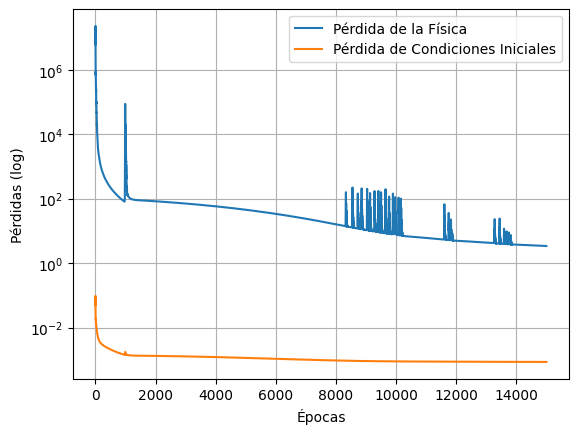

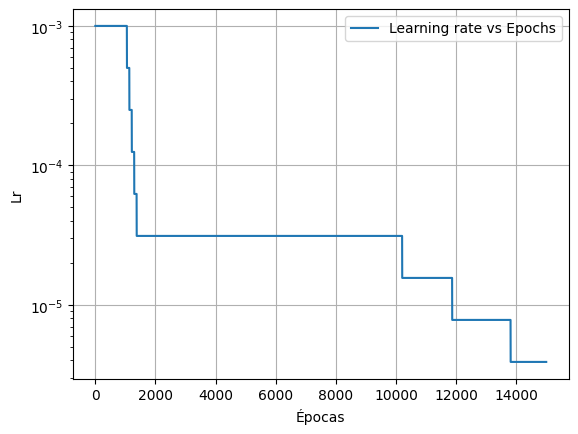


================ REPORTE DE ERROR MAE (ω = 5.50π) ================
Piso 1 -> MAE: 5.841944e-04 m
Piso 2 -> MAE: 8.720260e-04 m
Piso 3 -> MAE: 1.324369e-03 m
Piso 4 -> MAE: 1.487282e-03 m
----------------------------------------------------------------
MAE GLOBAL DEL EDIFICIO: 1.066968e-03 m

Piso 1: MAE = 5.841944e-04 m


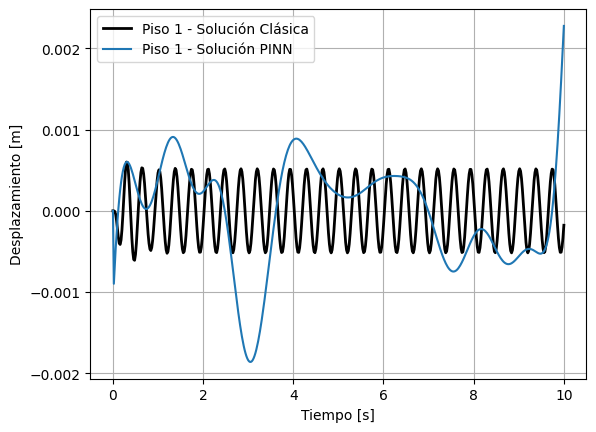

Piso 2: MAE = 8.720260e-04 m


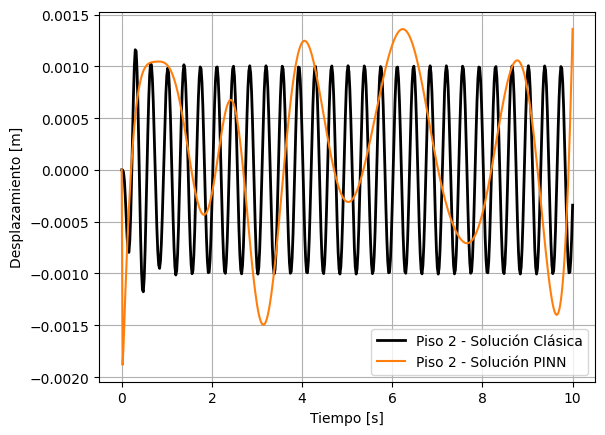

Piso 3: MAE = 1.324369e-03 m


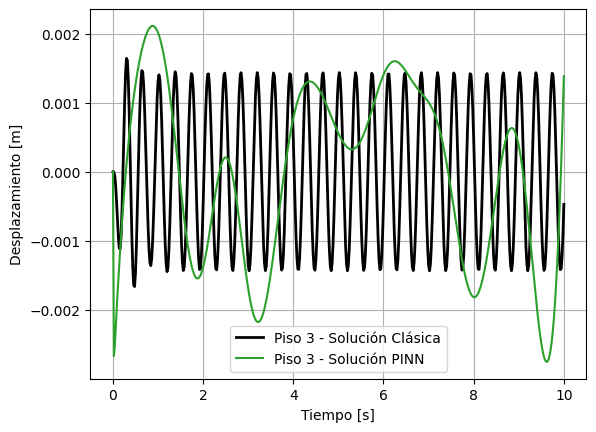

Piso 4: MAE = 1.487282e-03 m


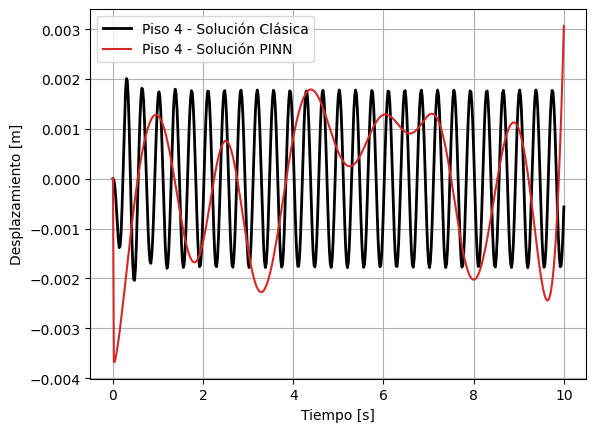

MAE Global: 1.066968e-03 m


In [62]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from time import time

class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, is_first=False, omega_0=30.0):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1 / self.linear.in_features
            else:
                bound = np.sqrt(6 / self.linear.in_features) / self.omega_0
            self.linear.weight.uniform_(-bound, bound)
            if self.linear.bias is not None:
                self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

class AutoregressivePINN_SIREN(nn.Module):
    def __init__(self, dim_in, dim_out, hidden_features=128, omega_0=30.0):
        super().__init__()
        self.net = nn.Sequential(
            SineLayer(dim_in, hidden_features, is_first=True, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            nn.Linear(hidden_features, dim_out)
        )
        with torch.no_grad():
            bound = np.sqrt(6 / hidden_features) / omega_0
            self.net[-1].weight.uniform_(-bound, bound)

    def forward(self, x):
        return self.net(x)




def generar_matriz_K_torch(N_dof, k_val, device='cpu'):
    """
    Genera la matriz de rigidez K acoplada para un edificio de N pisos en PyTorch.
    """
    # 1. Inicializar una matriz de ceros con el tamaño adecuado
    K = torch.zeros((N_dof, N_dof), dtype=torch.float32, device=device)

    # 2. Llenar la estructura tridiagonal para los pisos intermedios
    for i in range(N_dof - 1):
        K[i, i] = 2 * k_val      # Conectado con el piso de abajo y el de arriba
        K[i, i+1] = -k_val     # Acoplamiento con el piso superior
        K[i+1, i] = -k_val     # Acoplamiento simétrico

    # 3. Ajustar la condición de borde del techo (último piso)
    # El techo no tiene un piso arriba, por lo que su rigidez propia es solo k
    K[N_dof - 1, N_dof - 1] = k_val

    return K


def Generar_Contexto_Operacional(N_dof, t_step_max, rango_omega, m_val=80.0, k_val=400000.0, num_muestras=5000, tiempo_global=10):
    dim_entrada = 3 + 2 * N_dof

    m_vec = torch.tensor([m_val]*N_dof, device="cpu", dtype=torch.float32)
    K_torch = generar_matriz_K_torch(N_dof=N_dof, k_val=k_val, device="cpu")
    C_torch = 0.05 * torch.diag(m_vec) + 0.01 * K_torch

    sobol = torch.quasirandom.SobolEngine(dim_entrada)
    X_raw = sobol.draw(num_muestras)

    X_f = torch.zeros(num_muestras, dim_entrada, device="cpu")
    X_f[:, 0:1] = X_raw[:, 0:1] * tiempo_global
    X_f[:, 1:2] = X_raw[:, 1:2] * t_step_max
    X_f[:, 2:3] = X_raw[:, 2:3] * (rango_omega[1] - rango_omega[0]) + rango_omega[0] # omega

    # CORRECCIÓN: Rango físico realista. u0 en [-0.005, 0.005] m, v0 en [-0.05, 0.05] m/s
    X_f[:, 3:3+N_dof] = (X_raw[:, 3:3+N_dof] - 0.5) * 0.01
    X_f[:, 3+N_dof:] = (X_raw[:, 3+N_dof:] - 0.5) * 0.1
    X_f.requires_grad_(True)

    return (m_vec, K_torch, C_torch, X_f)


def Entrenar_Red(N_dof, t_step_max, M_vec, K, C, X_f, epochs, lam_amortiguamiento=1, learning_rate=1e-3, omega_red=5.0):
    print(f"Utilizando: {device}")
    m_vec = M_vec.to(device)
    K_torch = K.to(device)
    C_torch = C.to(device)
    X_f = X_f.to(device)

    dim_entrada = 3 + 2 * N_dof

    # CORRECCIÓN: Instanciamos la red SIREN (omega_0=30 funciona bien para tu problema)
    model = AutoregressivePINN_SIREN(dim_entrada, N_dof, omega_0=omega_red).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=80)

    Loss_f_list, Loss_ic_list, LR_list = [], [], []
    T0 = time()
    for epoch in range(1, epochs + 1):

        optimizer.zero_grad()

        t_abs = X_f[:, 0:1]
        t = X_f[:, 1:2]
        omega = X_f[:, 2:3]
        u0_input = X_f[:, 3:3+N_dof]
        v0_input = X_f[:, 3+N_dof:]

        u_f = model(X_f)

        u_t_list, u_tt_list = [], []
        for i in range(N_dof):
            g_u = torch.autograd.grad(u_f[:, i], X_f, torch.ones_like(u_f[:, i]), create_graph=True)[0]
            u_t_i = g_u[:, 1:2]
            u_t_list.append(u_t_i)
            u_tt_list.append(torch.autograd.grad(u_t_i, X_f, torch.ones_like(u_t_i), create_graph=True)[0][:, 1:2])

        u_t = torch.cat(u_t_list, dim=1)
        u_tt = torch.cat(u_tt_list, dim=1)

        # CORRECCIÓN 1: Tiempo actual (t_abs + t)
        t_current = t_abs + t
        F = torch.zeros_like(u_f)
        F[:, -1:] = -100.0 * torch.sin(omega * t_current)

        # CORRECCIÓN 2: Ecuación diferencial dividida por la masa
        # m_vec es un vector, al dividir aprovechamos el broadcasting tensor de PyTorch
        residual = u_tt + lam_amortiguamiento * (u_t @ C_torch.T) / m_vec + (u_f @ K_torch.T) / m_vec - F / m_vec
        loss_f = torch.mean(residual**2)

        X_ic = X_f.clone()
        X_ic[:, 1:2] = 0.0

        u_pred_0 = model(X_ic)

        u_t_0_list = []
        for i in range(N_dof):
            g_u0 = torch.autograd.grad(u_pred_0[:, i], X_ic, torch.ones_like(u_pred_0[:, i]), create_graph=True)[0]
            u_t_0_list.append(g_u0[:, 1:2])
        u_t_0 = torch.cat(u_t_0_list, dim=1)

        loss_ic = torch.mean((u_pred_0 - u0_input)**2) + torch.mean((u_t_0 - v0_input)**2)

        Loss_f_list.append(loss_f.item())
        Loss_ic_list.append(loss_ic.item())

        # CORRECCIÓN 3: Mayor peso a las condiciones iniciales para que no sean aplastadas
        lam_ic = 1e5
        loss_total = 1.0 * loss_f + lam_ic * loss_ic

        current_lr = optimizer.param_groups[0]['lr']
        LR_list.append(current_lr)

        loss_total.backward()
        optimizer.step()
        scheduler.step(loss_total)

        if epoch % (epochs//25) == 0 or epoch == 1:
            print(f"Época {epoch}/{epochs} | L_Total: {loss_total.item():.6e} | L_Física: {loss_f.item():.6e} | L_IC: {lam_ic*loss_ic.item():.6e} | Lr: {current_lr:.6e} | tiempo: {time()-T0:.2f}")

    plt.plot(Loss_f_list, label='Pérdida de la Física')
    plt.plot(Loss_ic_list, label='Pérdida de Condiciones Iniciales')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Pérdidas (log)')
    plt.yscale("log")
    plt.grid()
    plt.show()

    plt.plot(LR_list, label='Learning rate vs Epochs')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Lr')
    plt.yscale("log")
    plt.grid()
    plt.show()

    return model

def evaluar_y_cuantificar_pinn(model, N_dof, omega_test, m_val, k_val, tiempo_total=2.0, t_step_max=0.1):
    """
    Evalúa la PINN Autoregresiva en un horizonte largo mediante rolling inference,
    la compara con SciPy (RK45) y calcula el MAE (Mean Absolute Error).

    Argumentos:
    - model: Tu modelo PINN entrenado.
    - N_dof: Número de grados de libertad (pisos).
    - omega_test: Frecuencia paramétrica a evaluar (ej: 5.5 * np.pi).
    - tiempo_total: Tiempo total de la simulación extensa (por defecto 2.0s).
    - t_step_max: El paso delta_t con el que se entrenó la red (por defecto 0.1s).
    """
    # Verificar dispositivo del modelo
    device = next(model.parameters()).device
    model.eval()

    # 1. GENERACIÓN INTERNA DE MATRICES FÍSICAS (Basado en N_dof)


    M_np = np.diag([m_val] * N_dof)
    K_np = generar_matriz_K_torch(N_dof, k_val).numpy()
    C_np = 0.05 * M_np + 0.01 * K_np
    M_inv = np.linalg.inv(M_np)
    # 2. SIMULACIÓN TEMPORAL ENCADENADA (PINN ROLLING INFERENCE)
    pasos_totales = int(tiempo_total / t_step_max)

    historial_tiempo = [0.0]
    historial_desplazamientos = [np.zeros(N_dof)]

    u_actual = torch.zeros(1, N_dof, device=device)
    v_actual = torch.zeros(1, N_dof, device=device)
    t_delta_tensor = torch.tensor([[t_step_max]], device=device)
    omega_tensor = torch.tensor([[omega_test]], device=device)

    t_acumulado = 0.0

    for paso in range(pasos_totales):
        t_abs_tensor = torch.tensor([[t_acumulado]], device=device)

        # Concatena las 11 dimensiones en el orden exacto del entrenamiento:
        # [t_abs (1), t_rel (1), omega (1), u0 (4), v0 (4)] = 11 dimensiones
        X_step = torch.cat([t_abs_tensor, t_delta_tensor, omega_tensor, u_actual, v_actual], dim=1)
        X_step.requires_grad_(True)

        u_siguiente = model(X_step)

        # Bucle de velocidad con la corrección de retención de grafo
        v_siguiente_list = []
        for i in range(N_dof):
            g_u = torch.autograd.grad(
                u_siguiente[:, i],
                X_step,
                torch.ones_like(u_siguiente[:, i]),
                retain_graph=True
            )[0]
            v_siguiente_list.append(g_u[:, 1:2])
        v_siguiente = torch.cat(v_siguiente_list, dim=1)

        # Actualizar estados para el siguiente paso
        u_actual = u_siguiente.detach()
        v_actual = v_siguiente.detach()

        t_acumulado += t_step_max
        historial_tiempo.append(t_acumulado)
        historial_desplazamientos.append(u_actual.cpu().numpy()[0])

    u_pinn = np.array(historial_desplazamientos).T # Dimensión: (N_dof, pasos + 1)
    t_eval_pinn = np.array(historial_tiempo)

    # 3. SOLVER CLÁSICO (SciPy RK45) EVALUADO EN LOS MISMOS PUNTOS EXACTOS
    def sistema_NDOF(t, y):
        u = y[:N_dof]
        v = y[N_dof:]
        F = np.zeros(N_dof)
        F[-1] = -100.0 * np.sin(omega_test * t) # Fuerza en el techo
        dudt = v
        dvdt = M_inv @ (F - C_np @ v - K_np @ u)
        return np.concatenate([dudt, dvdt])

    y0 = np.zeros(2 * N_dof)
    solucion_exacta = solve_ivp(
        sistema_NDOF,
        (0.0, tiempo_total),
        y0,
        t_eval=t_eval_pinn, # Forzamos alineación temporal perfecta para restar matrices
        method='RK45'
    )
    u_clasico = solucion_exacta.y[:N_dof] # Dimensión: (N_dof, pasos + 1)

    # 4. CÁLCULO CUANTITATIVO DEL MAE (Mean Absolute Error)
    print(f"\n================ REPORTE DE ERROR MAE (ω = {omega_test/np.pi:.2f}π) ================")
    maes_por_piso = []

    for i in range(N_dof):
        # MAE = Mean(| u_real - u_pred |)
        mae_piso = np.mean(np.abs(u_clasico[i] - u_pinn[i]))
        maes_por_piso.append(mae_piso)
        print(f"Piso {i+1} -> MAE: {mae_piso:.6e} m")

    mae_global = np.mean(np.abs(u_clasico - u_pinn))
    print(f"----------------------------------------------------------------")
    print(f"MAE GLOBAL DEL EDIFICIO: {mae_global:.6e} m")
    print("================================================================\n")

    # Retorna los tiempos, la solución clásica, la solución pinn y el diccionario de métricas
    return t_eval_pinn, u_clasico, u_pinn, {"maes_pisos": maes_por_piso, "mae_global": mae_global}


print("MODELO SIREN")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_dof = 4
t_step_max = 0.02
rango_omega = (3 * np.pi, 7 * np.pi)    #Parámetro operacional variable
m_val, k_val = 80.0, 400000.0             # 80 tons y 40.000 kN/m^2
condiciones = Generar_Contexto_Operacional(n_dof, t_step_max, rango_omega, m_val, k_val, num_muestras=10000)
model = Entrenar_Red(n_dof, t_step_max, *condiciones, epochs=15000, lam_amortiguamiento=10, learning_rate=1e-3, omega_red=5.0)

time, u_clasico, u_pinn, metrics = evaluar_y_cuantificar_pinn(model, n_dof, omega_test=5.5 * np.pi, m_val=m_val, k_val=k_val, tiempo_total=10, t_step_max=t_step_max)

for piso, mae in enumerate(metrics["maes_pisos"]):
    print(f"Piso {piso+1}: MAE = {mae:.6e} m")
    plt.plot(time, u_clasico[piso], label=f'Piso {piso+1} - Solución Clásica', color='black', linewidth=2)
    plt.plot(time, u_pinn[piso], label=f'Piso {piso+1} - Solución PINN', color=f'C{piso}', linewidth=1.5)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Desplazamiento [m]')
    plt.grid()
    plt.legend()
    plt.show()
print(f"MAE Global: {metrics['mae_global']:.6e} m")

## Optimización de Hiperparámetros usando Optuna

In [ ]:
import optuna
import torch

# Asumo que ya tienes definidas tus funciones:
# Generar_Contexto_Operacional, AutoregressivePINN_SIREN, generar_matriz_K_torch...

def objective(trial):
    """
    Esta es la función que Optuna intentará minimizar.
    Cada vez que Optuna la ejecute, le pasará un objeto 'trial' con hiperparámetros distintos.
    """
    # ---------------------------------------------------------
    # 1. DEFINICIÓN DEL ESPACIO DE BÚSQUEDA (El cerebro de Optuna)
    # ---------------------------------------------------------
    # Optuna elegirá inteligentemente valores de estos rangos:

    # lr en escala logarítmica (buscará más exhaustivamente en los números pequeños)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    # omega_0: Sabemos que 30 explotó, busquemos entre 5 y 20
    omega_0 = trial.suggest_float("omega_0", 5.0, 20.0)

    # Peso de las condiciones iniciales
    lam_ic = trial.suggest_categorical("lam_ic", [1e3, 1e4, 1e5])

    # Tamaño de la red
    hidden_features = trial.suggest_categorical("hidden_features", [64, 128, 256])

    # ---------------------------------------------------------
    # 2. CONFIGURACIÓN DEL SISTEMA Y LA RED
    # ---------------------------------------------------------
    N_dof = 4
    t_step_max = 0.02
    rango_omega = (3 * np.pi, 7 * np.pi)
    m_val, k_val = 80.0, 400000.0

    # Generamos los datos (puedes sacarlo de la función objective para no recalcularlo,
    # pero aquí está por simplicidad)
    m_vec, K_torch, C_torch, X_f = Generar_Contexto_Operacional(N_dof, t_step_max, rango_omega, m_val, k_val)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    m_vec, K_torch, C_torch, X_f = m_vec.to(device), K_torch.to(device), C_torch.to(device), X_f.to(device)

    dim_entrada = 3 + 2 * N_dof

    # Inicializamos la red con los hiperparámetros sugeridos por el trial
    model = AutoregressivePINN_SIREN(dim_entrada, N_dof, hidden_features=hidden_features, omega_0=omega_0).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # ---------------------------------------------------------
    # 3. BUCLE DE ENTRENAMIENTO
    # ---------------------------------------------------------
    epochs = 15000 # Reducimos las épocas para la búsqueda rápida

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        t_abs = X_f[:, 0:1]
        t = X_f[:, 1:2]
        omega = X_f[:, 2:3]
        u0_input = X_f[:, 3:3+N_dof]
        v0_input = X_f[:, 3+N_dof:]

        u_f = model(X_f)

        u_t_list, u_tt_list = [], []
        for i in range(N_dof):
            g_u = torch.autograd.grad(u_f[:, i], X_f, torch.ones_like(u_f[:, i]), create_graph=True)[0]
            u_t_i = g_u[:, 1:2]
            u_t_list.append(u_t_i)
            u_tt_list.append(torch.autograd.grad(u_t_i, X_f, torch.ones_like(u_t_i), create_graph=True)[0][:, 1:2])

        u_t = torch.cat(u_t_list, dim=1)
        u_tt = torch.cat(u_tt_list, dim=1)

        t_current = t_abs + t
        F = torch.zeros_like(u_f)
        F[:, -1:] = -100.0 * torch.sin(omega * t_current)

        # Residual dividido por masa
        residual = u_tt + (u_t @ C_torch.T) / m_vec + (u_f @ K_torch.T) / m_vec - F / m_vec
        loss_f = torch.mean(residual**2)

        X_ic = X_f.clone()
        X_ic[:, 1:2] = 0.0
        u_pred_0 = model(X_ic)

        u_t_0_list = []
        for i in range(N_dof):
            g_u0 = torch.autograd.grad(u_pred_0[:, i], X_ic, torch.ones_like(u_pred_0[:, i]), create_graph=True)[0]
            u_t_0_list.append(g_u0[:, 1:2])
        u_t_0 = torch.cat(u_t_0_list, dim=1)

        loss_ic = torch.mean((u_pred_0 - u0_input)**2) + torch.mean((u_t_0 - v0_input)**2)

        # Función de costo global
        loss_total = 1.0 * loss_f + lam_ic * loss_ic

        loss_total.backward()
        optimizer.step()

        # ---------------------------------------------------------
        # 4. LA MAGIA DEL PRUNING (Podar ejecuciones malas)
        # ---------------------------------------------------------
        # Le reportamos a Optuna cómo va el loss cada 500 épocas
        if epoch % 500 == 0:
            trial.report(loss_total.item(), epoch)

            # Si Optuna detecta que este entrenamiento va peor que los anteriores,
            # lo aborta instantáneamente para no perder tiempo de CPU/GPU.
            if trial.should_prune():
                raise optuna.TrialPruned()

    # Optuna intentará minimizar el valor que retornes aquí
    return loss_total.item()

# ==========================================
# EJECUCIÓN DEL ESTUDIO
# ==========================================
if __name__ == "__main__":
    print("Iniciando Optimización Bayesiana con Optuna...")

    # MedianPruner mata los trials cuyo loss esté peor que la media histórica en esa misma época
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2000)

    estudio = optuna.create_study(direction="minimize", pruner=pruner)

    # Le decimos que haga 30 experimentos distintos (trials)
    estudio.optimize(objective, n_trials=30)

    print("\n--- ¡Búsqueda Finalizada! ---")
    print(f"Mejor valor de Loss: {estudio.best_value}")
    print("Mejores hiperparámetros encontrados:")
    for key, value in estudio.best_params.items():
        print(f"    {key}: {value}")

[I 2026-05-21 13:05:20,651] A new study created in memory with name: no-name-d2682212-2d23-427b-80aa-cf136ac38737


Iniciando Optimización Bayesiana con Optuna...


[I 2026-05-21 13:27:52,966] Trial 0 finished with value: 0.9453998804092407 and parameters: {'lr': 0.0003055147580741279, 'omega_0': 17.97810826591345, 'lam_ic': 1000.0, 'hidden_features': 128}. Best is trial 0 with value: 0.9453998804092407.
[I 2026-05-21 14:11:18,669] Trial 1 finished with value: 29.49142074584961 and parameters: {'lr': 0.0003092223372693969, 'omega_0': 17.155702415343086, 'lam_ic': 100000.0, 'hidden_features': 256}. Best is trial 0 with value: 0.9453998804092407.
[I 2026-05-21 14:54:27,958] Trial 2 finished with value: 124.66696166992188 and parameters: {'lr': 0.0013777966421772386, 'omega_0': 13.502142959532673, 'lam_ic': 100000.0, 'hidden_features': 256}. Best is trial 0 with value: 0.9453998804092407.
[I 2026-05-21 15:37:37,173] Trial 3 finished with value: 6.598515510559082 and parameters: {'lr': 0.00023719389299209443, 'omega_0': 16.001570962263667, 'lam_ic': 10000.0, 'hidden_features': 256}. Best is trial 0 with value: 0.9453998804092407.
[I 2026-05-21 15:51:5


--- ¡Búsqueda Finalizada! ---
Mejor valor de Loss: 0.9258957505226135
Mejores hiperparámetros encontrados:
    lr: 0.00031928369447326943
    omega_0: 16.036226851907674
    lam_ic: 1000.0
    hidden_features: 128


## SIREN con hiperaparámetros actualizados

MODELO SIREN
Utilizando: cuda
Época 1/50000 | L_Total: 1.428195e+00 | L_Física: 5.865268e-01 | L_IC: 8.416680e-01 | Lr: 3.192837e-04 | tiempo: 0.30
Época 2000/50000 | L_Total: 2.534009e-01 | L_Física: 1.177184e-02 | L_IC: 2.416291e-01 | Lr: 3.192837e-04 | tiempo: 334.16
Época 4000/50000 | L_Total: 2.466561e-01 | L_Física: 1.881149e-02 | L_IC: 2.278446e-01 | Lr: 3.192837e-04 | tiempo: 668.12
Época 6000/50000 | L_Total: 2.280652e-01 | L_Física: 4.444374e-03 | L_IC: 2.236209e-01 | Lr: 7.982092e-05 | tiempo: 1002.10
Época 8000/50000 | L_Total: 2.261351e-01 | L_Física: 4.048327e-03 | L_IC: 2.220868e-01 | Lr: 3.991046e-05 | tiempo: 1336.06
Época 10000/50000 | L_Total: 2.250257e-01 | L_Física: 3.822051e-03 | L_IC: 2.212036e-01 | Lr: 1.995523e-05 | tiempo: 1670.04
Época 12000/50000 | L_Total: 2.244256e-01 | L_Física: 3.845643e-03 | L_IC: 2.205800e-01 | Lr: 1.995523e-05 | tiempo: 2004.07
Época 14000/50000 | L_Total: 2.236528e-01 | L_Física: 3.611580e-03 | L_IC: 2.200412e-01 | Lr: 1.995523e-05 |

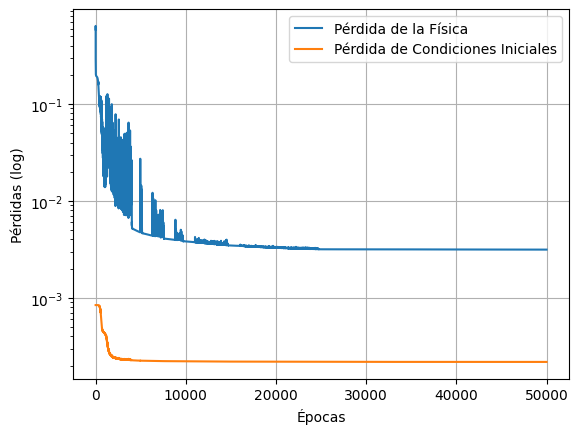

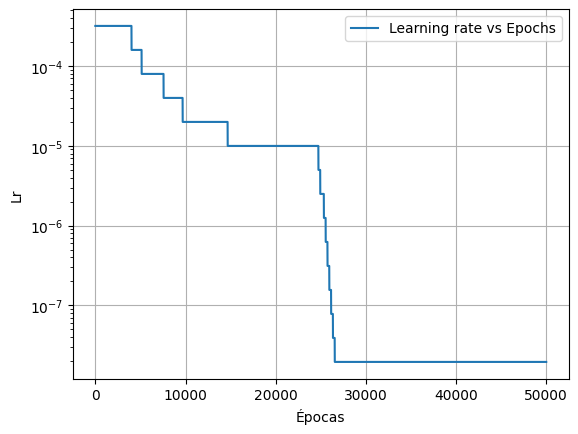


================ REPORTE DE ERROR MAE (ω = 5.50π) ================
Piso 1 -> MAE: 3.825264e-04 m
Piso 2 -> MAE: 6.868126e-04 m
Piso 3 -> MAE: 9.560168e-04 m
Piso 4 -> MAE: 1.153474e-03 m
----------------------------------------------------------------
MAE GLOBAL DEL EDIFICIO: 7.947075e-04 m

Piso 1: MAE = 3.825264e-04 m


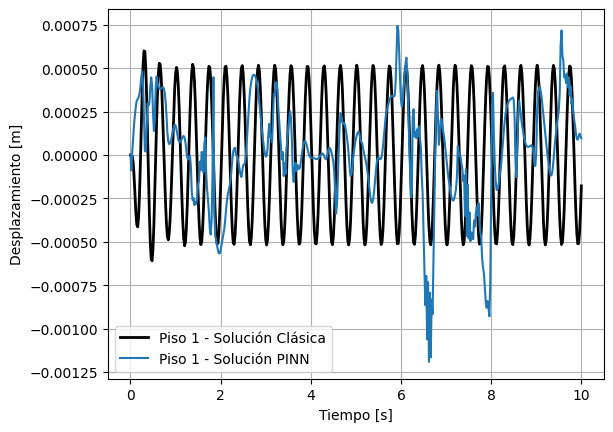

Piso 2: MAE = 6.868126e-04 m


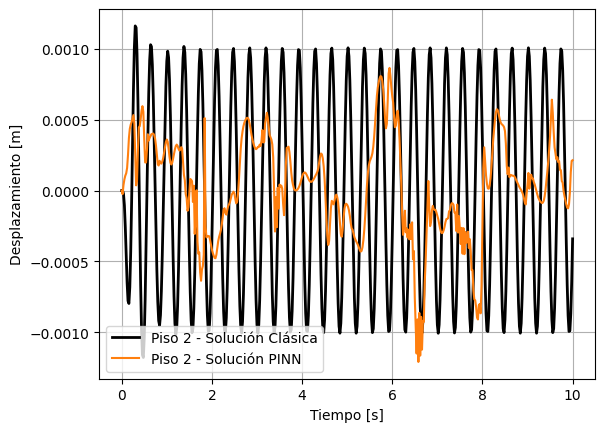

Piso 3: MAE = 9.560168e-04 m


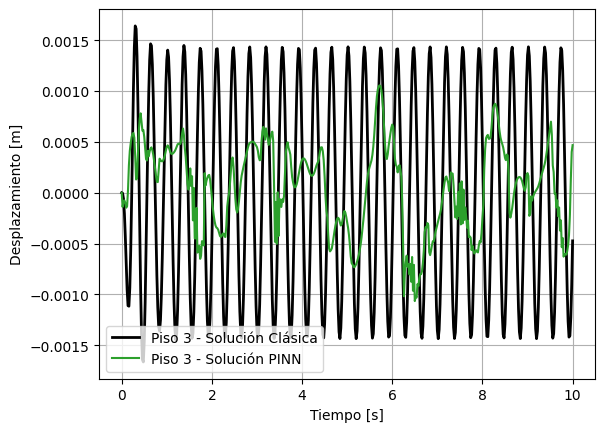

Piso 4: MAE = 1.153474e-03 m


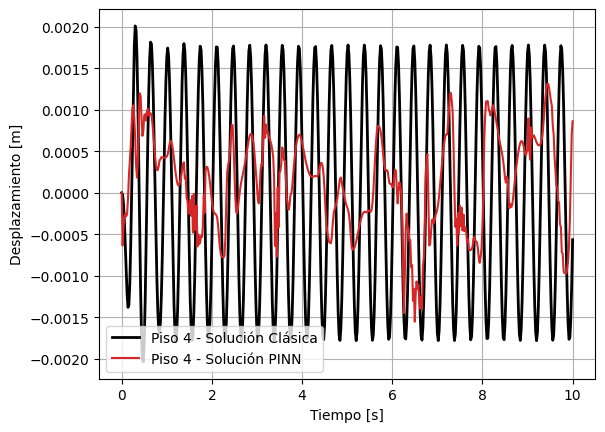

MAE Global: 7.947075e-04 m


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from time import time

class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, is_first=False, omega_0=18.0):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1 / self.linear.in_features
            else:
                bound = np.sqrt(6 / self.linear.in_features) / self.omega_0
            self.linear.weight.uniform_(-bound, bound)
            if self.linear.bias is not None:
                self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

class AutoregressivePINN_SIREN(nn.Module):
    def __init__(self, dim_in, dim_out, hidden_features=128, omega_0=30.0, escala_operacional=1e-3):
        super().__init__()
        self.escala = escala_operacional
        self.net = nn.Sequential(
            SineLayer(dim_in, hidden_features, is_first=True, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            nn.Linear(hidden_features, dim_out)
        )
        with torch.no_grad():
            bound = np.sqrt(6 / hidden_features) / omega_0
            self.net[-1].weight.uniform_(-bound, bound)


    def forward(self, x):
        raw_result = self.net(x)
        return raw_result*self.escala




def generar_matriz_K_torch(N_dof, k_val, device='cpu'):
    """
    Genera la matriz de rigidez K acoplada para un edificio de N pisos en PyTorch.
    """
    # 1. Inicializar una matriz de ceros con el tamaño adecuado
    K = torch.zeros((N_dof, N_dof), dtype=torch.float32, device=device)

    # 2. Llenar la estructura tridiagonal para los pisos intermedios
    for i in range(N_dof - 1):
        K[i, i] = 2 * k_val      # Conectado con el piso de abajo y el de arriba
        K[i, i+1] = -k_val     # Acoplamiento con el piso superior
        K[i+1, i] = -k_val     # Acoplamiento simétrico

    # 3. Ajustar la condición de borde del techo (último piso)
    # El techo no tiene un piso arriba, por lo que su rigidez propia es solo k
    K[N_dof - 1, N_dof - 1] = k_val

    return K


def Generar_Contexto_Operacional(N_dof, t_step_max, rango_omega, m_val=80.0, k_val=400000.0, num_muestras=5000, tiempo_global=10):
    dim_entrada = 3 + 2 * N_dof

    m_vec = torch.tensor([m_val]*N_dof, device="cpu", dtype=torch.float32)
    K_torch = generar_matriz_K_torch(N_dof=N_dof, k_val=k_val, device="cpu")
    C_torch = 0.05 * torch.diag(m_vec) + 0.01 * K_torch

    sobol = torch.quasirandom.SobolEngine(dim_entrada)
    X_raw = sobol.draw(num_muestras)

    X_f = torch.zeros(num_muestras, dim_entrada, device="cpu")
    X_f[:, 0:1] = X_raw[:, 0:1] * tiempo_global
    X_f[:, 1:2] = X_raw[:, 1:2] * t_step_max
    X_f[:, 2:3] = X_raw[:, 2:3] * (rango_omega[1] - rango_omega[0]) + rango_omega[0] # omega

    # CORRECCIÓN: Rango físico realista. u0 en [-0.005, 0.005] m, v0 en [-0.05, 0.05] m/s
    X_f[:, 3:3+N_dof] = (X_raw[:, 3:3+N_dof] - 0.5) * 0.01
    X_f[:, 3+N_dof:] = (X_raw[:, 3+N_dof:] - 0.5) * 0.1
    X_f.requires_grad_(True)

    return (m_vec, K_torch, C_torch, X_f)


def Entrenar_Red(N_dof, t_step_max, M_vec, K, C, X_f, epochs, omega_red=5, lam_amortiguamiento=1, learning_rate=1e-3):
    print(f"Utilizando: {device}")
    m_vec = M_vec.to(device)
    K_torch = K.to(device)
    C_torch = C.to(device)
    X_f = X_f.to(device)

    dim_entrada = 3 + 2 * N_dof

    # CORRECCIÓN: Instanciamos la red SIREN (omega_0=30 funciona bien para tu problema)
    model = AutoregressivePINN_SIREN(dim_entrada, N_dof, hidden_features=128, omega_0=omega_red).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=200)

    Loss_f_list, Loss_ic_list, LR_list = [], [], []
    T0 = time()
    for epoch in range(1, epochs + 1):

        optimizer.zero_grad()

        t_abs = X_f[:, 0:1]
        t = X_f[:, 1:2]
        omega = X_f[:, 2:3]
        u0_input = X_f[:, 3:3+N_dof]
        v0_input = X_f[:, 3+N_dof:]

        u_f = model(X_f)
        escala = 1e-3

        u_t_list, u_tt_list = [], []
        for i in range(N_dof):
            g_u = torch.autograd.grad(u_f[:, i], X_f, torch.ones_like(u_f[:, i]), create_graph=True)[0]
            u_t_i = g_u[:, 1:2]
            u_t_list.append(u_t_i)
            u_tt_list.append(torch.autograd.grad(u_t_i, X_f, torch.ones_like(u_t_i), create_graph=True)[0][:, 1:2])

        u_t = torch.cat(u_t_list, dim=1)
        u_tt = torch.cat(u_tt_list, dim=1)

        # CORRECCIÓN 1: Tiempo actual (t_abs + t)
        t_current = t_abs + t
        F = torch.zeros_like(u_f)
        F[:, -1:] = -100.0 * torch.sin(omega * t_current)

        # CORRECCIÓN 2: Ecuación diferencial dividida por la masa
        # m_vec es un vector, al dividir aprovechamos el broadcasting tensor de PyTorch
        residual = u_tt + lam_amortiguamiento * (u_t @ C_torch.T) / m_vec + (u_f @ K_torch.T) / m_vec - F / m_vec
        loss_f = torch.mean(residual**2)

        X_ic = X_f.clone()
        X_ic[:, 1:2] = 0.0

        u_pred_0 = model(X_ic)

        u_t_0_list = []
        for i in range(N_dof):
            g_u0 = torch.autograd.grad(u_pred_0[:, i], X_ic, torch.ones_like(u_pred_0[:, i]), create_graph=True)[0]
            u_t_0_list.append(g_u0[:, 1:2])
        u_t_0 = torch.cat(u_t_0_list, dim=1)

        loss_ic = torch.mean((u_pred_0 - u0_input)**2) + torch.mean((u_t_0 - v0_input)**2)

        Loss_f_list.append(loss_f.item())
        Loss_ic_list.append(loss_ic.item())

        # CORRECCIÓN 3: Mayor peso a las condiciones iniciales para que no sean aplastadas
        lam_ic = 1000.0
        loss_total = 1.0 * loss_f + lam_ic * loss_ic

        current_lr = optimizer.param_groups[0]['lr']
        LR_list.append(current_lr)

        loss_total.backward()
        optimizer.step()
        scheduler.step(loss_total)

        if epoch % (epochs//25) == 0 or epoch == 1:
            print(f"Época {epoch}/{epochs} | L_Total: {loss_total.item():.6e} | L_Física: {loss_f.item():.6e} | L_IC: {lam_ic*loss_ic.item():.6e} | Lr: {current_lr:.6e} | tiempo: {time()-T0:.2f}")

    plt.plot(Loss_f_list, label='Pérdida de la Física')
    plt.plot(Loss_ic_list, label='Pérdida de Condiciones Iniciales')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Pérdidas (log)')
    plt.yscale("log")
    plt.grid()
    plt.savefig(RUTA_PLOTS + "SIREN2_Loss.png", dpi=400, bbox_inches="tight")
    plt.show()

    plt.plot(LR_list, label='Learning rate vs Epochs')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Lr')
    plt.yscale("log")
    plt.grid()
    plt.savefig(RUTA_PLOTS + "SIREN2_Lr.png", dpi=400, bbox_inches="tight")
    plt.show()

    return model

def evaluar_y_cuantificar_pinn(model, N_dof, omega_test, m_val, k_val, tiempo_total=2.0, t_step_max=0.1):
    """
    Evalúa la PINN Autoregresiva en un horizonte largo mediante rolling inference,
    la compara con SciPy (RK45) y calcula el MAE (Mean Absolute Error).

    Argumentos:
    - model: Tu modelo PINN entrenado.
    - N_dof: Número de grados de libertad (pisos).
    - omega_test: Frecuencia paramétrica a evaluar (ej: 5.5 * np.pi).
    - tiempo_total: Tiempo total de la simulación extensa (por defecto 2.0s).
    - t_step_max: El paso delta_t con el que se entrenó la red (por defecto 0.1s).
    """
    # Verificar dispositivo del modelo
    device = next(model.parameters()).device
    model.eval()

    # 1. GENERACIÓN INTERNA DE MATRICES FÍSICAS (Basado en N_dof)


    M_np = np.diag([m_val] * N_dof)
    K_np = generar_matriz_K_torch(N_dof, k_val).numpy()
    C_np = 0.05 * M_np + 0.01 * K_np
    M_inv = np.linalg.inv(M_np)
    # 2. SIMULACIÓN TEMPORAL ENCADENADA (PINN ROLLING INFERENCE)
    pasos_totales = int(tiempo_total / t_step_max)

    historial_tiempo = [0.0]
    historial_desplazamientos = [np.zeros(N_dof)]

    u_actual = torch.zeros(1, N_dof, device=device)
    v_actual = torch.zeros(1, N_dof, device=device)
    t_delta_tensor = torch.tensor([[t_step_max]], device=device)
    omega_tensor = torch.tensor([[omega_test]], device=device)

    t_acumulado = 0.0

    for paso in range(pasos_totales):
        t_abs_tensor = torch.tensor([[t_acumulado]], device=device)

        # Concatena las 11 dimensiones en el orden exacto del entrenamiento:
        # [t_abs (1), t_rel (1), omega (1), u0 (4), v0 (4)] = 11 dimensiones
        X_step = torch.cat([t_abs_tensor, t_delta_tensor, omega_tensor, u_actual, v_actual], dim=1)
        X_step.requires_grad_(True)

        u_siguiente = model(X_step)

        # Bucle de velocidad con la corrección de retención de grafo
        v_siguiente_list = []
        for i in range(N_dof):
            g_u = torch.autograd.grad(
                u_siguiente[:, i],
                X_step,
                torch.ones_like(u_siguiente[:, i]),
                retain_graph=True
            )[0]
            v_siguiente_list.append(g_u[:, 1:2])
        v_siguiente = torch.cat(v_siguiente_list, dim=1)

        # Actualizar estados para el siguiente paso
        u_actual = u_siguiente.detach()
        v_actual = v_siguiente.detach()

        t_acumulado += t_step_max
        historial_tiempo.append(t_acumulado)
        historial_desplazamientos.append(u_actual.cpu().numpy()[0])

    u_pinn = np.array(historial_desplazamientos).T # Dimensión: (N_dof, pasos + 1)
    t_eval_pinn = np.array(historial_tiempo)

    # 3. SOLVER CLÁSICO (SciPy RK45) EVALUADO EN LOS MISMOS PUNTOS EXACTOS
    def sistema_NDOF(t, y):
        u = y[:N_dof]
        v = y[N_dof:]
        F = np.zeros(N_dof)
        F[-1] = -100.0 * np.sin(omega_test * t) # Fuerza en el techo
        dudt = v
        dvdt = M_inv @ (F - C_np @ v - K_np @ u)
        return np.concatenate([dudt, dvdt])

    y0 = np.zeros(2 * N_dof)
    solucion_exacta = solve_ivp(
        sistema_NDOF,
        (0.0, tiempo_total),
        y0,
        t_eval=t_eval_pinn, # Forzamos alineación temporal perfecta para restar matrices
        method='RK45'
    )
    u_clasico = solucion_exacta.y[:N_dof] # Dimensión: (N_dof, pasos + 1)

    # 4. CÁLCULO CUANTITATIVO DEL MAE (Mean Absolute Error)
    print(f"\n================ REPORTE DE ERROR MAE (ω = {omega_test/np.pi:.2f}π) ================")
    maes_por_piso = []

    for i in range(N_dof):
        # MAE = Mean(| u_real - u_pred |)
        mae_piso = np.mean(np.abs(u_clasico[i] - u_pinn[i]))
        maes_por_piso.append(mae_piso)
        print(f"Piso {i+1} -> MAE: {mae_piso:.6e} m")

    mae_global = np.mean(np.abs(u_clasico - u_pinn))
    print(f"----------------------------------------------------------------")
    print(f"MAE GLOBAL DEL EDIFICIO: {mae_global:.6e} m")
    print("================================================================\n")

    # Retorna los tiempos, la solución clásica, la solución pinn y el diccionario de métricas
    return t_eval_pinn, u_clasico, u_pinn, {"maes_pisos": maes_por_piso, "mae_global": mae_global}


# Testeando Scheduler CosineAnnealing


print("MODELO SIREN")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_dof = 4
t_step_max = 0.02
rango_omega = (3 * np.pi, 7 * np.pi)    #Parámetro operacional variable
m_val, k_val = 80.0, 400000.0             # 80 tons y 40.000 kN/m^2
condiciones = Generar_Contexto_Operacional(n_dof, t_step_max, rango_omega, m_val, k_val, num_muestras=10000)
model = Entrenar_Red(n_dof, t_step_max, *condiciones, epochs=50000, omega_red=16.036226851907674, lam_amortiguamiento=1, learning_rate=0.00031928369447326943)

time, u_clasico, u_pinn, metrics = evaluar_y_cuantificar_pinn(model, n_dof, omega_test=5.5 * np.pi, m_val=m_val, k_val=k_val, tiempo_total=10, t_step_max=t_step_max)

for piso, mae in enumerate(metrics["maes_pisos"]):
    print(f"Piso {piso+1}: MAE = {mae:.6e} m")
    plt.plot(time, u_clasico[piso], label=f'Piso {piso+1} - Solución Clásica', color='black', linewidth=2)
    plt.plot(time, u_pinn[piso], label=f'Piso {piso+1} - Solución PINN', color=f'C{piso}', linewidth=1.5)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Desplazamiento [m]')
    plt.grid()
    plt.legend()
    plt.savefig(RUTA_PLOTS + f"SIREN2_piso{piso+1}.png", dpi=400, bbox_inches="tight")
    plt.show()
print(f"MAE Global: {metrics['mae_global']:.6e} m")

## SIREN con SOAP

In [1]:
# Optimizador SOAP
import torch
import torch.nn as nn
import torch.optim as optim

from itertools import chain

# Parts of the code are modifications of Pytorch's AdamW optimizer
# Parts of the code are modifications of code from https://github.com/jiaweizzhao/GaLore/blob/master/galore_torch/galore_projector.py
# CÓDIGO DE https://github.com/nikhilvyas/SOAP/blob/main/soap.py
# USO INSPIRADO POR PAPER https://arxiv.org/pdf/2602.19265
class SOAP(optim.Optimizer):
    """
    Implements SOAP algorithm (https://arxiv.org/abs/2409.11321).

    Parameters:
        params (`Iterable[nn.parameter.Parameter]`):
            Iterable of parameters to optimize or dictionaries defining parameter groups.
        lr (`float`, *optional*, defaults to 0.003):
            The learning rate to use.
        betas (`Tuple[float,float]`, *optional*, defaults to `(0.95, 0.95)`):
            Adam's betas parameters (b1, b2).
        shampoo_beta (`float`, *optional*, defaults to -1):
            If >= 0, use this beta for the preconditioner (L and R in paper, state['GG'] below) moving average instead of betas[1].
        eps (`float`, *optional*, defaults to 1e-08):
            Adam's epsilon for numerical stability.
        weight_decay (`float`, *optional*, defaults to 0.01): weight decay coefficient.
        precondition_frequency (`int`, *optional*, defaults to 10):
            How often to update the preconditioner.
        max_precond_dim (`int`, *optional*, defaults to 10000):
            Maximum dimension of the preconditioner.
            Set to 10000, so that we exclude most common vocab sizes while including layers.
        merge_dims (`bool`, *optional*, defaults to `False`):
            Whether or not to merge dimensions of the preconditioner.
        precondition_1d (`bool`, *optional*, defaults to `False`):
            Whether or not to precondition 1D gradients.
        normalize_grads (`bool`, *optional*, defaults to `False`):
            Whether or not to normalize gradients per layer.
            Helps at large precondition_frequency (~100 in our experiments),
            but hurts performance at small precondition_frequency (~10 in our experiments).
        data_format (`str`, *optional*, defaults to `channels_first`):
            Data format of the input for convolutional layers.
            Should be "channels_last" for data_format of NHWC and "channels_first" for NCHW.
        correct_bias (`bool`, *optional*, defaults to `True`):
            Whether or not to use bias correction in Adam.
    """

    def __init__(
        self,
        params,
        lr: float = 3e-3,
        betas=(0.95, 0.95),
        shampoo_beta: float= -1,
        eps: float = 1e-8,
        weight_decay: float = 0.01,
        precondition_frequency: int=10,
        max_precond_dim: int=10000, #
        merge_dims: bool = False, # Merge dimensions till the product of the dimensions is less than or equal to max_precond_dim.
        precondition_1d: bool = False,
        normalize_grads: bool = False,
        data_format: str = "channels_first",
        correct_bias: bool = True,
    ):
        defaults = {
            "lr": lr,
            "betas": betas,
            "shampoo_beta": shampoo_beta,
            "eps": eps,
            "weight_decay": weight_decay,
            "precondition_frequency": precondition_frequency,
            "max_precond_dim": max_precond_dim,
            "merge_dims": merge_dims,
            "precondition_1d": precondition_1d,
            "normalize_grads": normalize_grads,
            "correct_bias": correct_bias,
        }
        super().__init__(params, defaults)
        self._data_format = data_format

    def merge_dims(self, grad, max_precond_dim):
        """
        Merges dimensions of the gradient tensor till the product of the dimensions is less than or equal to max_precond_dim.
        """
        assert self._data_format in ["channels_first", "channels_last"]
        if self._data_format == "channels_last" and grad.dim() == 4:
            grad = grad.permute(0, 3, 1, 2)
        shape = grad.shape
        new_shape = []

        curr_shape = 1
        for sh in shape:
            temp_shape = curr_shape * sh
            if temp_shape > max_precond_dim:
                if curr_shape > 1:
                    new_shape.append(curr_shape)
                    curr_shape = sh
                else:
                    new_shape.append(sh)
                    curr_shape = 1
            else:
                curr_shape = temp_shape

        if curr_shape > 1 or len(new_shape)==0:
            new_shape.append(curr_shape)

        new_grad = grad.reshape(new_shape)
        return new_grad

    @torch.no_grad()
    def step(self, closure = None):
        """
        Performs a single optimization step.

        Arguments:
            closure (`Callable`, *optional*): A closure that reevaluates the model and returns the loss.
        """
        if closure is None:
            loss = None
        else:
            loss = closure()

        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad

                state = self.state[p]

                if "step" not in state:
                    state["step"] = 0

                # State initialization
                if "exp_avg" not in state:
                    # Exponential moving average of gradient values
                    state["exp_avg"] = torch.zeros_like(grad)
                    # Exponential moving average of squared gradient values
                    state["exp_avg_sq"] = torch.zeros_like(grad)

                if 'Q' not in state:
                    self.init_preconditioner(
                        grad,
                        state,
                        precondition_frequency=group['precondition_frequency'],
                        precondition_1d=group['precondition_1d'],
                        shampoo_beta=(group['shampoo_beta'] if group['shampoo_beta'] >= 0 else group["betas"][1]),
                        max_precond_dim=group['max_precond_dim'],
                        merge_dims=group["merge_dims"],
                    )
                    self.update_preconditioner(grad, state,
                                               max_precond_dim=group['max_precond_dim'],
                                               merge_dims=group["merge_dims"],
                                               precondition_1d=group["precondition_1d"])
                    continue # first step is skipped so that we never use the current gradients in the projection.

                # Projecting gradients to the eigenbases of Shampoo's preconditioner
                # i.e. projecting to the eigenbases of matrices in state['GG']
                grad_projected = self.project(grad, state, merge_dims=group["merge_dims"],
                                              max_precond_dim=group['max_precond_dim'])

                exp_avg, exp_avg_sq = state["exp_avg"], state["exp_avg_sq"]
                beta1, beta2 = group["betas"]

                state["step"] += 1

                # Decay the first and second moment running average coefficient
                # In-place operations to update the averages at the same time
                exp_avg.mul_(beta1).add_(grad_projected, alpha=(1.0 - beta1))
                exp_avg_sq.mul_(beta2).add_(grad_projected.square(), alpha=(1.0 - beta2))

                denom = exp_avg_sq.sqrt().add_(group["eps"])

                # Projecting the exponential moving average of gradients to the eigenbases of Shampoo's preconditioner
                # i.e. projecting to the eigenbases of matrices in state['GG']
                # exp_avg_projected = self.project(exp_avg, state, merge_dims=group["merge_dims"],
                #                                  max_precond_dim=group['max_precond_dim'])
                exp_avg_projected = exp_avg

                step_size = group["lr"]
                if group["correct_bias"]:
                    bias_correction1 = 1.0 - beta1 ** (state["step"])
                    bias_correction2 = 1.0 - beta2 ** (state["step"])
                    step_size = step_size * (bias_correction2 ** .5) / bias_correction1

                # Projecting back the preconditioned (by Adam) exponential moving average of gradients
                # to the original space
                norm_grad = self.project_back(exp_avg_projected / denom, state, merge_dims=group["merge_dims"],
                                                 max_precond_dim=group['max_precond_dim'])

                if group["normalize_grads"]:
                    norm_grad = norm_grad / (1e-30+torch.mean(norm_grad**2)**0.5)

                p.add_(norm_grad, alpha=-step_size)


                # From AdamW code: Just adding the square of the weights to the loss function is *not*
                # the correct way of using L2 regularization/weight decay with Adam,
                # since that will interact with the m and v parameters in strange ways.
                #
                # Instead we want to decay the weights in a manner that doesn't interact
                # with the m/v parameters. This is equivalent to adding the square
                # of the weights to the loss with plain (non-momentum) SGD.
                # Add weight decay at the end (fixed version)
                if group["weight_decay"] > 0.0:
                    p.add_(p, alpha=(-group["lr"] * group["weight_decay"]))

                # Update is done after the gradient step to avoid using current gradients in the projection.
                self.update_preconditioner(grad, state,
                                               max_precond_dim=group['max_precond_dim'],
                                               merge_dims=group["merge_dims"],
                                               precondition_1d=group["precondition_1d"])

        return loss

    def init_preconditioner(self, grad, state, precondition_frequency=10,
                            shampoo_beta=0.95, max_precond_dim=10000, precondition_1d=False,
                            merge_dims=False):
        """
        Initializes the preconditioner matrices (L and R in the paper).
        """
        state['GG'] = [] # Will hold all the preconditioner matrices (L and R in the paper).
        if grad.dim() == 1:
            if not precondition_1d or grad.shape[0] > max_precond_dim:
                state['GG'].append([])
            else:
                state['GG'].append(torch.zeros(grad.shape[0], grad.shape[0], device=grad.device))
        else:
            if merge_dims:
                grad = self.merge_dims(grad, max_precond_dim)

            for sh in grad.shape:
                if sh > max_precond_dim:
                    state['GG'].append([])
                else:
                    state['GG'].append(torch.zeros(sh, sh, device=grad.device))

        state['Q'] = None # Will hold all the eigenbases of the preconditioner.
        state['precondition_frequency'] = precondition_frequency
        state['shampoo_beta'] = shampoo_beta

    def project(self, grad, state, merge_dims=False, max_precond_dim=10000):
        """
        Projects the gradient to the eigenbases of the preconditioner.
        """
        original_shape = grad.shape
        if merge_dims:
            if grad.dim() == 4 and self._data_format == 'channels_last':
                permuted_shape = grad.permute(0, 3, 1, 2).shape
            grad = self.merge_dims(grad, max_precond_dim)

        for mat in state['Q']:
            if len(mat) > 0:
                grad = torch.tensordot(
                        grad,
                        mat,
                        dims=[[0], [0]],
                    )
            else:
                permute_order = list(range(1, len(grad.shape))) + [0]
                grad = grad.permute(permute_order)

        if merge_dims:
            if self._data_format == 'channels_last' and len(original_shape) == 4:
                grad = grad.reshape(permuted_shape).permute(0, 2, 3, 1)
            else:
                grad = grad.reshape(original_shape)
        return grad

    def update_preconditioner(self, grad, state,
                              max_precond_dim=10000, merge_dims=False, precondition_1d=False):
        """
        Updates the preconditioner matrices and the eigenbases (L, R, Q_L, Q_R in the paper).
        """
        if state["Q"] is not None:
            state["exp_avg"] = self.project_back(state["exp_avg"], state, merge_dims=merge_dims, max_precond_dim=max_precond_dim)
        if grad.dim() == 1:
            if precondition_1d and grad.shape[0] <= max_precond_dim:
                state['GG'][0].lerp_(grad.unsqueeze(1) @ grad.unsqueeze(0), 1-state['shampoo_beta'])
        else:
            if merge_dims:
                new_grad = self.merge_dims(grad, max_precond_dim)
                for idx, sh in enumerate(new_grad.shape):
                    if sh <= max_precond_dim:
                        outer_product = torch.tensordot(
                                new_grad,
                                new_grad,
                                dims=[[*chain(range(idx), range(idx + 1, len(new_grad.shape)))]] * 2,
                            )
                        state['GG'][idx].lerp_(outer_product, 1-state['shampoo_beta'])
            else:
                for idx, sh in enumerate(grad.shape):
                    if sh <= max_precond_dim:
                        outer_product = torch.tensordot(
                                grad,
                                grad,
                                # Contracts across all dimensions except for k.
                                dims=[[*chain(range(idx), range(idx + 1, len(grad.shape)))]] * 2,
                            )
                        state['GG'][idx].lerp_(outer_product, 1-state['shampoo_beta'])

        if state['Q'] is None:
            state['Q'] = self.get_orthogonal_matrix(state['GG'])
        if state['step'] > 0 and state['step'] % state['precondition_frequency'] == 0:
            state['Q'] = self.get_orthogonal_matrix_QR(state, max_precond_dim, merge_dims)
            # state['Q'] = self.get_fast_QR(state, max_precond_dim, merge_dims)

        if state["step"] > 0:
            state["exp_avg"] = self.project(state["exp_avg"], state, merge_dims=merge_dims, max_precond_dim=max_precond_dim)

    def project_back(self, grad, state, merge_dims=False, max_precond_dim=10000):
        """
        Projects the gradient back to the original space.
        """
        original_shape = grad.shape
        if merge_dims:
            if self._data_format == 'channels_last' and grad.dim() == 4:
                permuted_shape = grad.permute(0, 3, 1, 2).shape
            grad = self.merge_dims(grad, max_precond_dim)
        for mat in state['Q']:
            if len(mat) > 0:
                grad = torch.tensordot(
                        grad,
                        mat,
                        dims=[[0], [1]],
                    )
            else:
                permute_order = list(range(1, len(grad.shape))) + [0]
                grad = grad.permute(permute_order)

        if merge_dims:
            if self._data_format == 'channels_last' and len(original_shape) == 4:
                grad = grad.reshape(permuted_shape).permute(0, 2, 3, 1)
            else:
                grad = grad.reshape(original_shape)
        return grad


    def get_orthogonal_matrix(self, mat):
        """
        Computes the eigenbases of the preconditioner using torch.linalg.eigh decomposition.
        """
        matrix = []
        for m in mat:
            if len(m) == 0:
                matrix.append([])
                continue
            if m.data.dtype != torch.float:
                float_data = False
                original_type = m.data.dtype
                original_device = m.data.device
                matrix.append(m.data.float())
            else:
                float_data = True
                matrix.append(m.data)

        final = []
        for m in matrix:
            if len(m) == 0:
                final.append([])
                continue
            try:
                _, Q = torch.linalg.eigh(m+1e-30*torch.eye(m.shape[0], device=m.device))
            except:
                _, Q = torch.linalg.eigh(m.to(torch.float64)+1e-30*torch.eye(m.shape[0], device=m.device))
                Q = Q.to(m.dtype)
            Q = torch.flip(Q, [1])

            if not float_data:
                Q = Q.to(original_device).type(original_type)
            final.append(Q)
        return final


    def get_orthogonal_matrix_QR(self, state, max_precond_dim=10000, merge_dims=False):
        """
        Computes the eigenbases of the preconditioner using one round of power iteration
        followed by torch.linalg.qr decomposition.
        """
        precond_list = state['GG']
        orth_list = state['Q']

        matrix = []
        orth_matrix = []
        for m,o in zip(precond_list, orth_list):
            if len(m) == 0:
                matrix.append([])
                orth_matrix.append([])
                continue
            if m.data.dtype != torch.float:
                float_data = False
                original_type = m.data.dtype
                original_device = m.data.device
                matrix.append(m.data.float())
                orth_matrix.append(o.data.float())
            else:
                float_data = True
                matrix.append(m.data.float())
                orth_matrix.append(o.data.float())

        orig_shape = state['exp_avg_sq'].shape
        if self._data_format == 'channels_last' and len(orig_shape) == 4:
            permuted_shape = state['exp_avg_sq'].permute(0, 3, 1, 2).shape
        if merge_dims:
            exp_avg_sq = self.merge_dims(state['exp_avg_sq'], max_precond_dim)
        else:
            exp_avg_sq = state['exp_avg_sq']

        final = []
        for ind, (m,o) in enumerate(zip(matrix, orth_matrix)):
            if len(m)==0:
                final.append([])
                continue
            est_eig = torch.diag(o.T @ m @ o)
            sort_idx = torch.argsort(est_eig, descending=True)
            exp_avg_sq = exp_avg_sq.index_select(ind, sort_idx)
            o = o[:,sort_idx]
            power_iter = m @ o
            Q, _ = torch.linalg.qr(power_iter)

            if not float_data:
                Q = Q.to(original_device).type(original_type)
            final.append(Q)

        if merge_dims:
            if self._data_format == 'channels_last' and len(orig_shape) == 4:
                exp_avg_sq = exp_avg_sq.reshape(permuted_shape).permute(0, 2, 3, 1)
            else:
                exp_avg_sq = exp_avg_sq.reshape(orig_shape)

        state['exp_avg_sq'] = exp_avg_sq
        return final



MODELO SIREN
Utilizando: cuda
Época 1/50000 | L_Total: 4.028378e+00 | L_Física: 6.616467e-01 | L_IC: 3.366731e+00 | Lr: 1.000000e-03 | tiempo: 0.36
Época 2000/50000 | L_Total: 3.250161e-02 | L_Física: 2.066280e-03 | L_IC: 3.043533e-02 | Lr: 5.000000e-04 | tiempo: 354.96
Época 4000/50000 | L_Total: 2.661124e-02 | L_Física: 9.961326e-04 | L_IC: 2.561511e-02 | Lr: 2.500000e-04 | tiempo: 708.78
Época 6000/50000 | L_Total: 2.168797e-02 | L_Física: 3.961060e-04 | L_IC: 2.129186e-02 | Lr: 1.250000e-04 | tiempo: 1063.15
Época 8000/50000 | L_Total: 2.019579e-02 | L_Física: 5.621031e-04 | L_IC: 1.963369e-02 | Lr: 1.250000e-04 | tiempo: 1417.13
Época 10000/50000 | L_Total: 1.850952e-02 | L_Física: 4.142959e-04 | L_IC: 1.809522e-02 | Lr: 6.250000e-05 | tiempo: 1770.49
Época 12000/50000 | L_Total: 1.730087e-02 | L_Física: 6.032544e-04 | L_IC: 1.669762e-02 | Lr: 6.250000e-05 | tiempo: 2124.81
Época 14000/50000 | L_Total: 1.567077e-02 | L_Física: 6.128853e-04 | L_IC: 1.505789e-02 | Lr: 6.250000e-05 |

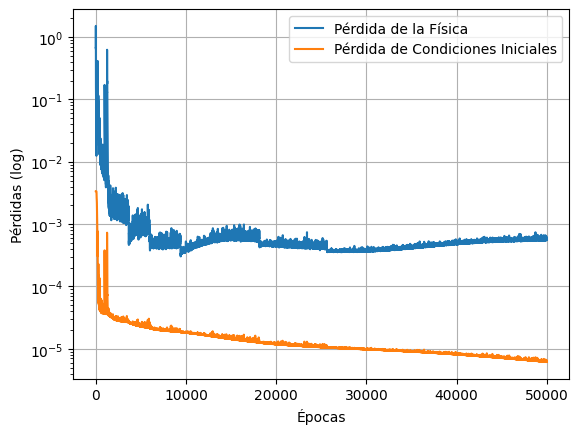

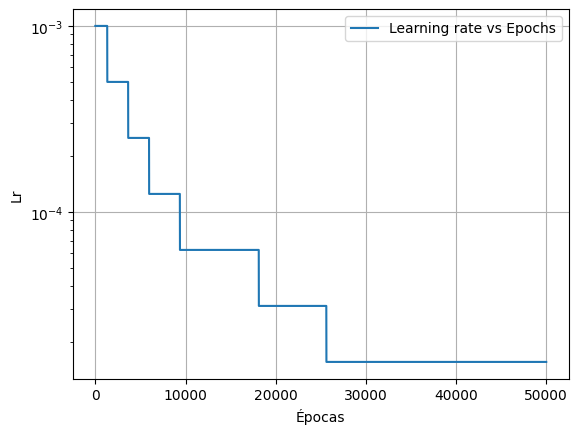


================ REPORTE DE ERROR MAE (ω = 5.50π) ================
Piso 1 -> MAE: 2.030136e-04 m
Piso 2 -> MAE: 3.816514e-04 m
Piso 3 -> MAE: 5.182926e-04 m
Piso 4 -> MAE: 5.928512e-04 m
----------------------------------------------------------------
MAE GLOBAL DEL EDIFICIO: 4.239522e-04 m

Piso 1: MAE = 2.030136e-04 m


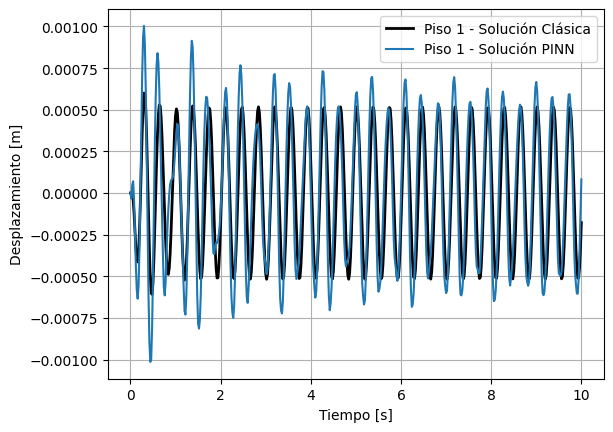

Piso 2: MAE = 3.816514e-04 m


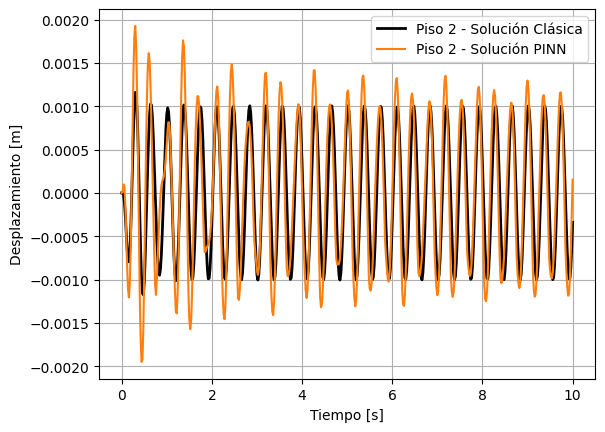

Piso 3: MAE = 5.182926e-04 m


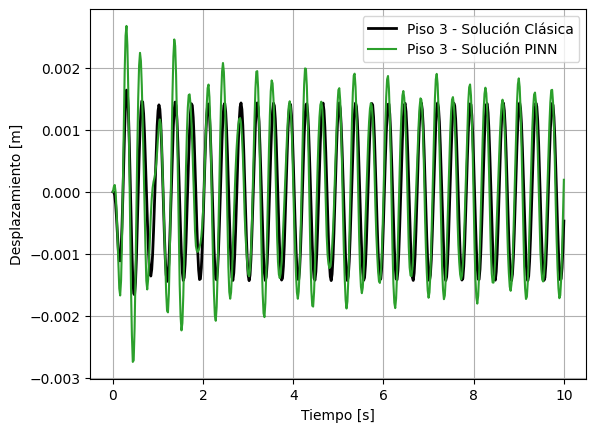

Piso 4: MAE = 5.928512e-04 m


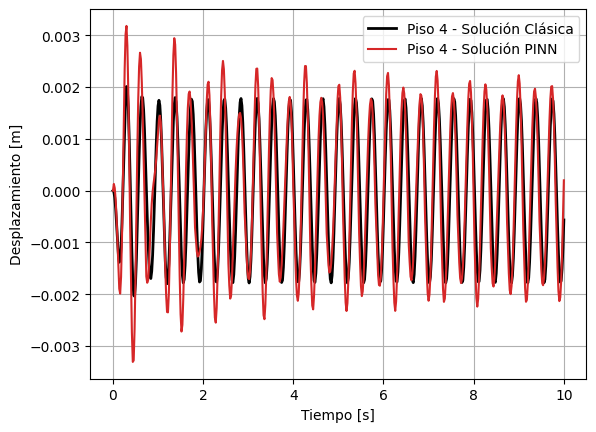

MAE Global: 4.239522e-04 m


In [ ]:
# Modelo
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from time import time

class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, is_first=False, omega_0=18.0):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1 / self.linear.in_features
            else:
                bound = np.sqrt(6 / self.linear.in_features) / self.omega_0
            self.linear.weight.uniform_(-bound, bound)
            if self.linear.bias is not None:
                self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

class AutoregressivePINN_SIREN(nn.Module):
    def __init__(self, dim_in, dim_out, hidden_features=128, omega_0=30.0, escala_operacional=1e-3):
        super().__init__()
        self.escala = escala_operacional
        self.net = nn.Sequential(
            SineLayer(dim_in, hidden_features, is_first=True, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            nn.Linear(hidden_features, dim_out)
        )
        with torch.no_grad():
            bound = np.sqrt(6 / hidden_features) / omega_0
            self.net[-1].weight.uniform_(-bound, bound)


    def forward(self, x):
        raw_result = self.net(x)
        return raw_result*self.escala




def generar_matriz_K_torch(N_dof, k_val, device='cpu'):
    """
    Genera la matriz de rigidez K acoplada para un edificio de N pisos en PyTorch.
    """
    # 1. Inicializar una matriz de ceros con el tamaño adecuado
    K = torch.zeros((N_dof, N_dof), dtype=torch.float32, device=device)

    # 2. Llenar la estructura tridiagonal para los pisos intermedios
    for i in range(N_dof - 1):
        K[i, i] = 2 * k_val      # Conectado con el piso de abajo y el de arriba
        K[i, i+1] = -k_val     # Acoplamiento con el piso superior
        K[i+1, i] = -k_val     # Acoplamiento simétrico

    # 3. Ajustar la condición de borde del techo (último piso)
    # El techo no tiene un piso arriba, por lo que su rigidez propia es solo k
    K[N_dof - 1, N_dof - 1] = k_val

    return K


def Generar_Contexto_Operacional(N_dof, t_step_max, rango_omega, m_val=80.0, k_val=400000.0, num_muestras=5000, tiempo_global=10):
    dim_entrada = 3 + 2 * N_dof

    m_vec = torch.tensor([m_val]*N_dof, device="cpu", dtype=torch.float32)
    K_torch = generar_matriz_K_torch(N_dof=N_dof, k_val=k_val, device="cpu")
    C_torch = 0.05 * torch.diag(m_vec) + 0.01 * K_torch

    sobol = torch.quasirandom.SobolEngine(dim_entrada)
    X_raw = sobol.draw(num_muestras)



    X_f = torch.zeros(num_muestras, dim_entrada, device="cpu")

    X_f[:, 1:2] = X_raw[:, 1:2] * t_step_max
    X_f[:, 2:3] = X_raw[:, 2:3] * (rango_omega[1] - rango_omega[0]) + rango_omega[0] # omega

    T_periodo = 2 * np.pi / X_f[:, 2:3] # T = 2π / omega
    t_abs_bruto = X_raw[:, 0:1] * tiempo_global
    X_f[:, 0:1] = torch.remainder(t_abs_bruto, T_periodo)   # Mapeo circular: t_abs siempre estará entre [0, T_periodo]


    # CORRECCIÓN: Rango físico realista. u0 en [-0.005, 0.005] m, v0 en [-0.05, 0.05] m/s
    X_f[:, 3:3+N_dof] = (X_raw[:, 3:3+N_dof] - 0.5) * 0.02
    X_f[:, 3+N_dof:] = (X_raw[:, 3+N_dof:] - 0.5) * 0.2
    X_f.requires_grad_(True)

    return (m_vec, K_torch, C_torch, X_f)


def Entrenar_Red(N_dof, t_step_max, M_vec, K, C, X_f, epochs, omega_red=5, lam_amortiguamiento=1, learning_rate=1e-3):
    print(f"Utilizando: {device}")
    m_vec = M_vec.to(device)
    K_torch = K.to(device)
    C_torch = C.to(device)
    X_f = X_f.to(device)

    dim_entrada = 3 + 2 * N_dof

    # CORRECCIÓN: Instanciamos la red SIREN (omega_0=30 funciona bien para tu problema)
    model = AutoregressivePINN_SIREN(dim_entrada, N_dof, hidden_features=128, omega_0=omega_red).to(device)

    # optimizer = SOAP(model.parameters(), lr=learning_rate)
    optimizer = SOAP(model.parameters(), lr=1e-3, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=200)
    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    Loss_f_list, Loss_ic_list, LR_list = [], [], []
    T0 = time()
    for epoch in range(1, epochs + 1):

        optimizer.zero_grad()

        t_abs = X_f[:, 0:1]
        t = X_f[:, 1:2]
        omega = X_f[:, 2:3]
        u0_input = X_f[:, 3:3+N_dof]
        v0_input = X_f[:, 3+N_dof:]

        u_f = model(X_f)
        escala = 1e-3

        u_t_list, u_tt_list = [], []
        for i in range(N_dof):
            g_u = torch.autograd.grad(u_f[:, i], X_f, torch.ones_like(u_f[:, i]), create_graph=True)[0]
            u_t_i = g_u[:, 1:2]
            u_t_list.append(u_t_i)
            u_tt_list.append(torch.autograd.grad(u_t_i, X_f, torch.ones_like(u_t_i), create_graph=True)[0][:, 1:2])

        u_t = torch.cat(u_t_list, dim=1)
        u_tt = torch.cat(u_tt_list, dim=1)

        # CORRECCIÓN 1: Tiempo actual (t_abs + t)
        t_current = t_abs + t
        F = torch.zeros_like(u_f)
        F[:, -1:] = -100.0 * torch.sin(omega * t_current)

        # CORRECCIÓN 2: Ecuación diferencial dividida por la masa
        # m_vec es un vector, al dividir aprovechamos el broadcasting tensor de PyTorch
        residual = u_tt + lam_amortiguamiento * (u_t @ C_torch.T) / m_vec + (u_f @ K_torch.T) / m_vec - F / m_vec
        loss_f = torch.mean(residual**2)

        X_ic = X_f.clone()
        X_ic[:, 1:2] = 0.0

        u_pred_0 = model(X_ic)

        u_t_0_list = []
        for i in range(N_dof):
            g_u0 = torch.autograd.grad(u_pred_0[:, i], X_ic, torch.ones_like(u_pred_0[:, i]), create_graph=True)[0]
            u_t_0_list.append(g_u0[:, 1:2])
        u_t_0 = torch.cat(u_t_0_list, dim=1)

        loss_ic = torch.mean((u_pred_0 - u0_input)**2) + torch.mean((u_t_0 - v0_input)**2)

        Loss_f_list.append(loss_f.item())
        Loss_ic_list.append(loss_ic.item())

        # CORRECCIÓN 3: Mayor peso a las condiciones iniciales para que no sean aplastadas
        lam_ic = 1000.0
        loss_total = 1.0 * loss_f + lam_ic * loss_ic

        current_lr = optimizer.param_groups[0]['lr']
        LR_list.append(current_lr)

        loss_total.backward()
        optimizer.step()
        scheduler.step(loss_total)

        if epoch % (epochs//25) == 0 or epoch == 1:
            print(f"Época {epoch}/{epochs} | L_Total: {loss_total.item():.6e} | L_Física: {loss_f.item():.6e} | L_IC: {lam_ic*loss_ic.item():.6e} | Lr: {current_lr:.6e} | tiempo: {time()-T0:.2f}")

    plt.plot(Loss_f_list, label='Pérdida de la Física')
    plt.plot(Loss_ic_list, label='Pérdida de Condiciones Iniciales')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Pérdidas (log)')
    plt.yscale("log")
    plt.grid()
    plt.savefig(RUTA_PLOTS + "SIREN_SOAP_Loss.png", dpi=400, bbox_inches="tight")
    plt.show()

    plt.plot(LR_list, label='Learning rate vs Epochs')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Lr')
    plt.yscale("log")
    plt.grid()
    plt.savefig(RUTA_PLOTS + "SIREN_SOAP_Loss.png", dpi=400, bbox_inches="tight")
    plt.show()

    return model

def evaluar_y_cuantificar_pinn(model, N_dof, omega_test, m_val, k_val, tiempo_total=2.0, t_step_max=0.1):
    """
    Evalúa la PINN Autoregresiva en un horizonte largo mediante rolling inference,
    la compara con SciPy (RK45) y calcula el MAE (Mean Absolute Error).

    Argumentos:
    - model: Tu modelo PINN entrenado.
    - N_dof: Número de grados de libertad (pisos).
    - omega_test: Frecuencia paramétrica a evaluar (ej: 5.5 * np.pi).
    - tiempo_total: Tiempo total de la simulación extensa (por defecto 2.0s).
    - t_step_max: El paso delta_t con el que se entrenó la red (por defecto 0.1s).
    """
    # Verificar dispositivo del modelo
    device = next(model.parameters()).device
    model.eval()

    # 1. GENERACIÓN INTERNA DE MATRICES FÍSICAS (Basado en N_dof)


    M_np = np.diag([m_val] * N_dof)
    K_np = generar_matriz_K_torch(N_dof, k_val).numpy()
    C_np = 0.05 * M_np + 0.01 * K_np
    M_inv = np.linalg.inv(M_np)
    # 2. SIMULACIÓN TEMPORAL ENCADENADA (PINN ROLLING INFERENCE)
    pasos_totales = int(tiempo_total / t_step_max)

    historial_tiempo = [0.0]
    historial_desplazamientos = [np.zeros(N_dof)]

    u_actual = torch.zeros(1, N_dof, device=device)
    v_actual = torch.zeros(1, N_dof, device=device)
    t_delta_tensor = torch.tensor([[t_step_max]], device=device)
    omega_tensor = torch.tensor([[omega_test]], device=device)
    T_test = 2 * np.pi / omega_test
    t_acumulado = 0.0

    for paso in range(pasos_totales):



        # Mapear el tiempo de vuelta al primer periodo de forma continua
        t_abs_mapeado = t_acumulado % T_test

        # Pasarle el tiempo mapeado a la red, NO el tiempo acumulado bruto
        t_abs_tensor = torch.tensor([[t_abs_mapeado]], device=device)

        X_step = torch.cat([t_abs_tensor, t_delta_tensor, omega_tensor, u_actual, v_actual], dim=1)
        X_step.requires_grad_(True)

        u_siguiente = model(X_step)

        # Bucle de velocidad con la corrección de retención de grafo
        v_siguiente_list = []
        for i in range(N_dof):
            g_u = torch.autograd.grad(
                u_siguiente[:, i],
                X_step,
                torch.ones_like(u_siguiente[:, i]),
                retain_graph=True
            )[0]
            v_siguiente_list.append(g_u[:, 1:2])
        v_siguiente = torch.cat(v_siguiente_list, dim=1)

        # Actualizar estados para el siguiente paso
        u_actual = u_siguiente.detach()
        v_actual = v_siguiente.detach()

        t_acumulado += t_step_max

        historial_tiempo.append(t_acumulado)
        historial_desplazamientos.append(u_actual.cpu().numpy()[0])

    u_pinn = np.array(historial_desplazamientos).T # Dimensión: (N_dof, pasos + 1)
    t_eval_pinn = np.array(historial_tiempo)

    # 3. SOLVER CLÁSICO (SciPy RK45) EVALUADO EN LOS MISMOS PUNTOS EXACTOS
    def sistema_NDOF(t, y):
        u = y[:N_dof]
        v = y[N_dof:]
        F = np.zeros(N_dof)
        F[-1] = -100.0 * np.sin(omega_test * t) # Fuerza en el techo
        dudt = v
        dvdt = M_inv @ (F - C_np @ v - K_np @ u)
        return np.concatenate([dudt, dvdt])

    y0 = np.zeros(2 * N_dof)
    solucion_exacta = solve_ivp(
        sistema_NDOF,
        (0.0, tiempo_total),
        y0,
        t_eval=t_eval_pinn, # Forzamos alineación temporal perfecta para restar matrices
        method='RK45'
    )
    u_clasico = solucion_exacta.y[:N_dof] # Dimensión: (N_dof, pasos + 1)

    # 4. CÁLCULO CUANTITATIVO DEL MAE (Mean Absolute Error)
    print(f"\n================ REPORTE DE ERROR MAE (ω = {omega_test/np.pi:.2f}π) ================")
    maes_por_piso = []

    for i in range(N_dof):
        # MAE = Mean(| u_real - u_pred |)
        mae_piso = np.mean(np.abs(u_clasico[i] - u_pinn[i]))
        maes_por_piso.append(mae_piso)
        print(f"Piso {i+1} -> MAE: {mae_piso:.6e} m")

    mae_global = np.mean(np.abs(u_clasico - u_pinn))
    print(f"----------------------------------------------------------------")
    print(f"MAE GLOBAL DEL EDIFICIO: {mae_global:.6e} m")
    print("================================================================\n")

    # Retorna los tiempos, la solución clásica, la solución pinn y el diccionario de métricas
    return t_eval_pinn, u_clasico, u_pinn, {"maes_pisos": maes_por_piso, "mae_global": mae_global}



print("MODELO SIREN")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_dof = 4
t_step_max = 0.02
rango_omega = (3 * np.pi, 7 * np.pi)    #Parámetro operacional variable
m_val, k_val = 80.0, 400000.0             # 80 tons y 40.000 kN/m^2
N_epochs = 50000
omega_red = 16.036226851907674
Lr = 0.00031928369447326943

condiciones = Generar_Contexto_Operacional(n_dof, t_step_max, rango_omega, m_val, k_val, num_muestras=10000)
model = Entrenar_Red(n_dof, t_step_max, *condiciones, epochs=N_epochs, omega_red=omega_red, lam_amortiguamiento=1, learning_rate=Lr)

time, u_clasico, u_pinn, metrics = evaluar_y_cuantificar_pinn(model, n_dof, omega_test=5.5 * np.pi, m_val=m_val, k_val=k_val, tiempo_total=10, t_step_max=t_step_max)

for piso, mae in enumerate(metrics["maes_pisos"]):
    print(f"Piso {piso+1}: MAE = {mae:.6e} m")
    plt.plot(time, u_clasico[piso], label=f'Piso {piso+1} - Solución Clásica', color='black', linewidth=2)
    plt.plot(time, u_pinn[piso], label=f'Piso {piso+1} - Solución PINN', color=f'C{piso}', linewidth=1.5)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Desplazamiento [m]')
    plt.grid()
    plt.legend()
    plt.savefig(RUTA_PLOTS + f"SIREN_SOAP_piso{piso+1}.png", dpi=400, bbox_inches="tight")
    plt.show()
print(f"MAE Global: {metrics['mae_global']:.6e} m")

## 2a optimización: Optuna usando SOAP

In [ ]:
import optuna
import torch
import numpy as np
import os

class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, is_first=False, omega_0=18.0):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1 / self.linear.in_features
            else:
                bound = np.sqrt(6 / self.linear.in_features) / self.omega_0
            self.linear.weight.uniform_(-bound, bound)
            if self.linear.bias is not None:
                self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

class AutoregressivePINN_SIREN(nn.Module):
    def __init__(self, dim_in, dim_out, hidden_features=128, omega_0=30.0, escala_operacional=1e-3):
        super().__init__()
        self.escala = escala_operacional
        self.net = nn.Sequential(
            SineLayer(dim_in, hidden_features, is_first=True, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            nn.Linear(hidden_features, dim_out)
        )
        with torch.no_grad():
            bound = np.sqrt(6 / hidden_features) / omega_0
            self.net[-1].weight.uniform_(-bound, bound)


    def forward(self, x):
        raw_result = self.net(x)
        return raw_result*self.escala




def generar_matriz_K_torch(N_dof, k_val, device='cpu'):
    """
    Genera la matriz de rigidez K acoplada para un edificio de N pisos en PyTorch.
    """
    # 1. Inicializar una matriz de ceros con el tamaño adecuado
    K = torch.zeros((N_dof, N_dof), dtype=torch.float32, device=device)

    # 2. Llenar la estructura tridiagonal para los pisos intermedios
    for i in range(N_dof - 1):
        K[i, i] = 2 * k_val      # Conectado con el piso de abajo y el de arriba
        K[i, i+1] = -k_val     # Acoplamiento con el piso superior
        K[i+1, i] = -k_val     # Acoplamiento simétrico

    # 3. Ajustar la condición de borde del techo (último piso)
    # El techo no tiene un piso arriba, por lo que su rigidez propia es solo k
    K[N_dof - 1, N_dof - 1] = k_val

    return K


def Generar_Contexto_Operacional(N_dof, t_step_max, rango_omega, m_val=80.0, k_val=400000.0, num_muestras=5000, tiempo_global=10):
    dim_entrada = 3 + 2 * N_dof

    m_vec = torch.tensor([m_val]*N_dof, device="cpu", dtype=torch.float32)
    K_torch = generar_matriz_K_torch(N_dof=N_dof, k_val=k_val, device="cpu")
    C_torch = 0.05 * torch.diag(m_vec) + 0.01 * K_torch

    sobol = torch.quasirandom.SobolEngine(dim_entrada)
    X_raw = sobol.draw(num_muestras)



    X_f = torch.zeros(num_muestras, dim_entrada, device="cpu")

    X_f[:, 1:2] = X_raw[:, 1:2] * t_step_max
    X_f[:, 2:3] = X_raw[:, 2:3] * (rango_omega[1] - rango_omega[0]) + rango_omega[0] # omega

    T_periodo = 2 * np.pi / X_f[:, 2:3] # T = 2π / omega
    t_abs_bruto = X_raw[:, 0:1] * tiempo_global
    X_f[:, 0:1] = torch.remainder(t_abs_bruto, T_periodo)   # Mapeo circular: t_abs siempre estará entre [0, T_periodo]


    # CORRECCIÓN: Rango físico realista. u0 en [-0.005, 0.005] m, v0 en [-0.05, 0.05] m/s
    X_f[:, 3:3+N_dof] = (X_raw[:, 3:3+N_dof] - 0.5) * 0.02
    X_f[:, 3+N_dof:] = (X_raw[:, 3+N_dof:] - 0.5) * 0.2
    X_f.requires_grad_(True)

    return (m_vec, K_torch, C_torch, X_f)




# ==========================================
# 1. CALLBACK PARA GUARDAR EL MEJOR MODELO
# ==========================================
def guardar_mejor_modelo(study, trial):
    """
    Esta función se ejecuta al final de cada Trial.
    Si el Trial actual es el mejor hasta ahora, guarda los pesos en el disco.
    """
    if study.best_trial.number == trial.number:
        # Se asume que el modelo fue guardado temporalmente por la función objective
        # Aquí solo notificamos o podemos mover el archivo definitivo
        print(f"🌟 ¡Nuevo récord en el Trial {trial.number}! Loss: {trial.value:.6e} - Modelo guardado.")

# ==========================================
# 2. FUNCIÓN OBJETIVO (El Bucle de Entrenamiento)
# ==========================================
def objective(trial):
    # --- Espacio de Búsqueda ---
    lr = trial.suggest_float("lr", 1e-4, 2e-3, log=True)
    omega_0 = trial.suggest_float("omega_0", 15.0, 22.0)
    lam_ic = trial.suggest_float("lam_ic", 500.0, 5000.0, log=True)
    hidden_features = trial.suggest_categorical("hidden_features", [64, 128])

    # --- Configuración Física ---
    N_dof = 4
    t_step_max = 0.02
    rango_omega = (3 * np.pi, 7 * np.pi)
    m_val, k_val = 80.0, 400000.0

    # Generar datos (Asegúrate de tener la modificación del mapeo de t_abs en esta función)
    m_vec, K_torch, C_torch, X_f = Generar_Contexto_Operacional(N_dof, t_step_max, rango_omega, m_val, k_val, num_muestras=15000)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    m_vec, K_torch, C_torch, X_f = m_vec.to(device), K_torch.to(device), C_torch.to(device), X_f.to(device)

    dim_entrada = 3 + 2 * N_dof

    # Usamos la clase con escala_u interno, SIN el Ansatz
    model = AutoregressivePINN_SIREN(dim_entrada, N_dof, hidden_features=hidden_features, omega_0=omega_0, escala_operacional=0.001).to(device)

    optimizer = SOAP(model.parameters(), lr=1e-3, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=200)

    epochs = 20000 # 20k es suficiente para que Optuna evalúe el potencial de la red

    # --- Bucle de Entrenamiento ---
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        # 1. PREDICCIÓN Y FÍSICA
        u_f = model(X_f)

        u_t_list, u_tt_list = [], []
        for i in range(N_dof):
            g_u = torch.autograd.grad(u_f[:, i], X_f, torch.ones_like(u_f[:, i]), create_graph=True)[0]
            u_t_i = g_u[:, 1:2]
            u_t_list.append(u_t_i)
            u_tt_list.append(torch.autograd.grad(u_t_i, X_f, torch.ones_like(u_t_i), create_graph=True)[0][:, 1:2])

        u_t = torch.cat(u_t_list, dim=1)
        u_tt = torch.cat(u_tt_list, dim=1)

        # Reconstrucción de la fuerza externa (Global Time)
        t_abs = X_f[:, 0:1]
        t_local = X_f[:, 1:2]
        omega = X_f[:, 2:3]
        t_global = t_abs + t_local

        F = torch.zeros_like(u_f)
        F[:, -1:] = -100.0 * torch.sin(omega * t_global)

        residual = u_tt + (u_t @ C_torch.T) / m_vec + (u_f @ K_torch.T) / m_vec - F / m_vec
        loss_f = torch.mean(residual**2)

        # 2. CONDICIONES INICIALES (Soft Constraints restauradas)
        X_ic = X_f.clone()
        X_ic[:, 1:2] = 0.0
        u_pred_0 = model(X_ic)

        u_t_0_list = []
        for i in range(N_dof):
            g_u0 = torch.autograd.grad(u_pred_0[:, i], X_ic, torch.ones_like(u_pred_0[:, i]), create_graph=True)[0]
            u_t_0_list.append(g_u0[:, 1:2])
        u_t_0 = torch.cat(u_t_0_list, dim=1)

        u0_input = X_f[:, 3:3+N_dof]
        v0_input = X_f[:, 3+N_dof:]

        loss_ic = torch.mean((u_pred_0 - u0_input)**2) + torch.mean((u_t_0 - v0_input)**2)

        # 3. PÉRDIDA TOTAL Y RETROPROPAGACIÓN
        loss_total = loss_f + lam_ic * loss_ic

        loss_total.backward()
        optimizer.step()
        scheduler.step(loss_total) # Adam scheduler step

        # --- PRUNING (Poda) ---
        if epoch % 500 == 0:
            trial.report(loss_total.item(), epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    # Si este trial termina completo, guardamos temporalmente sus pesos
    torch.save(model.state_dict(), f"temp_siren_trial_{trial.number}.pth")

    # Le pasamos el loss final a Optuna
    return loss_total.item()

# ==========================================
# 3. EJECUCIÓN DEL ESTUDIO (Overnight)
# ==========================================
if __name__ == "__main__":
    print("Iniciando sesión de entrenamiento nocturna...")

    # 1. Base de datos SQLite para persistencia
    # Si detienes el script y lo vuelves a correr, Optuna leerá este archivo
    # y continuará exactamente donde se quedó.
    db_name = "sqlite:///optimizacion_nocturna_siren.db"
    study_name = "siren_structural_dynamics"

    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3000)

    # create_study con load_if_exists permite reanudar entrenamientos caídos
    estudio = optuna.create_study(
        study_name=study_name,
        storage=db_name,
        direction="minimize",
        pruner=pruner,
        load_if_exists=True
    )

    # 2. Correr el optimizador
    # n_trials=100 asegurará que esté corriendo toda la noche.
    # Usamos la función de callback para monitorear el mejor modelo.
    try:
        estudio.optimize(objective, n_trials=100, callbacks=[guardar_mejor_modelo])
    except KeyboardInterrupt:
        print("\nEntrenamiento interrumpido manualmente. El progreso está a salvo en la base de datos.")

    # 3. Limpieza y guardado final
    print("\n--- ¡Búsqueda Finalizada! ---")
    print(f"Mejor valor de Loss: {estudio.best_value}")
    print("Mejores hiperparámetros:")
    for key, value in estudio.best_params.items():
        print(f"    {key}: {value}")

    # Renombrar el archivo del mejor trial para fácil acceso y borrar los temporales
    mejor_trial_id = estudio.best_trial.number
    if os.path.exists(f"temp_siren_trial_{mejor_trial_id}.pth"):
        os.rename(f"temp_siren_trial_{mejor_trial_id}.pth", "MEJOR_MODELO_SIREN.pth")
        print("\n✅ Pesos de la mejor red guardados exitosamente como 'MEJOR_MODELO_SIREN.pth'")

    # Limpiar basura de trials intermedios
    for f in os.listdir("."):
        if f.startswith("temp_siren_trial_"):
            os.remove(f)

[I 2026-05-26 20:24:47,729] Using an existing study with name 'siren_structural_dynamics' instead of creating a new one.


Iniciando sesión de entrenamiento nocturna...


[I 2026-05-26 21:49:11,864] Trial 2 finished with value: 0.020545335486531258 and parameters: {'lr': 0.00029160271178901837, 'omega_0': 15.448164198151202, 'lam_ic': 2022.5679852447156, 'hidden_features': 128}. Best is trial 2 with value: 0.020545335486531258.


🌟 ¡Nuevo récord en el Trial 2! Loss: 2.054534e-02 - Modelo guardado.


[I 2026-05-26 23:13:20,826] Trial 3 finished with value: 0.009350073523819447 and parameters: {'lr': 0.00011345912526719726, 'omega_0': 20.850523314026095, 'lam_ic': 725.7356372227765, 'hidden_features': 128}. Best is trial 3 with value: 0.009350073523819447.


...

🌟 ¡Nuevo récord en el Trial 4! Loss: 5.909274e-03 - Modelo guardado.


[I 2026-05-27 01:25:34,851] Trial 5 finished with value: 0.01086260937154293 and parameters: {'lr': 0.00016219154965689973, 'omega_0': 18.681018494231477, 'lam_ic': 575.347246026138, 'hidden_features': 64}. Best is trial 4 with value: 0.005909273866564035.
[I 2026-05-27 02:12:18,899] Trial 6 finished with value: 0.031061148270964622 and parameters: {'lr': 0.0010769774350668706, 'omega_0': 20.28383178497014, 'lam_ic': 1218.4285607889087, 'hidden_features': 64}. Best is trial 4 with value: 0.005909273866564035.
[I 2026-05-27 02:31:00,233] Trial 7 pruned. 
[I 2026-05-27 02:43:35,898] Trial 8 pruned. 
[I 2026-05-27 02:56:11,978] Trial 9 pruned. 
[I 2026-05-27 03:08:47,700] Trial 10 pruned. 
[I 2026-05-27 03:15:48,289] Trial 11 pruned. 
[I 2026-05-27 03:28:23,783] Trial 12 pruned. 
[I 2026-05-27 04:52:22,130] Trial 13 finished with value: 0.007309961132705212 and parameters: {'lr': 0.00010170448158800461, 'omega_0': 19.31551785923416, 'lam_ic': 594.1756473479257, 'hidden_features': 128}. Be

🌟 ¡Nuevo récord en el Trial 33! Loss: 3.165266e-03 - Modelo guardado.


[I 2026-05-27 15:11:30,588] Trial 34 pruned. 
[I 2026-05-27 16:11:06,888] Trial 35 pruned. 
[I 2026-05-27 16:26:00,706] Trial 36 pruned. 
[I 2026-05-27 16:44:50,468] Trial 37 pruned. 
[I 2026-05-27 17:52:57,581] Trial 38 pruned. 
[I 2026-05-27 18:00:01,645] Trial 39 pruned. 
[I 2026-05-27 18:12:47,754] Trial 40 pruned. 
[I 2026-05-27 18:25:33,728] Trial 41 pruned. 
[I 2026-05-27 18:32:37,272] Trial 42 pruned. 
[I 2026-05-27 19:57:43,476] Trial 43 finished with value: 0.006491184234619141 and parameters: {'lr': 0.00020239729158534167, 'omega_0': 18.04851563639427, 'lam_ic': 533.9691366590545, 'hidden_features': 128}. Best is trial 33 with value: 0.003165265778079629.
[I 2026-05-27 20:55:09,701] Trial 44 pruned. 
[I 2026-05-27 21:07:55,634] Trial 45 pruned. 
[I 2026-05-27 22:15:59,392] Trial 46 pruned. 
[W 2026-05-27 22:26:37,197] Trial 47 failed with parameters: {'lr': 0.0002099812413618855, 'omega_0': 19.864715687883052, 'lam_ic': 578.3057055541982, 'hidden_features': 128} because of t


Entrenamiento interrumpido manualmente. El progreso está a salvo en la base de datos.

--- ¡Búsqueda Finalizada! ---
Mejor valor de Loss: 0.003165265778079629
Mejores hiperparámetros:
    lr: 0.00020969512321501158
    omega_0: 18.261291103470565
    lam_ic: 504.53183753538866
    hidden_features: 128

✅ Pesos de la mejor red guardados exitosamente como 'MEJOR_MODELO_SIREN.pth'


## SIREN SOAP post optimización 2.0

MODELO SIREN
Utilizando: cuda
Época 1/50000 | L_Total: 2.220439e+00 | L_Física: 5.218623e-01 | L_IC: 1.698577e+00 | Lr: 1.000000e-03 | tiempo: 0.44
Época 2000/50000 | L_Total: 1.841237e-02 | L_Física: 1.821380e-03 | L_IC: 1.659099e-02 | Lr: 5.000000e-04 | tiempo: 357.01
Época 4000/50000 | L_Total: 1.416245e-02 | L_Física: 5.392193e-04 | L_IC: 1.362323e-02 | Lr: 2.500000e-04 | tiempo: 716.28
Época 6000/50000 | L_Total: 1.328991e-02 | L_Física: 3.682293e-04 | L_IC: 1.292168e-02 | Lr: 1.250000e-04 | tiempo: 1072.46
Época 8000/50000 | L_Total: 1.213862e-02 | L_Física: 4.006453e-04 | L_IC: 1.173797e-02 | Lr: 1.250000e-04 | tiempo: 1435.45
Época 10000/50000 | L_Total: 1.135428e-02 | L_Física: 4.157009e-04 | L_IC: 1.093858e-02 | Lr: 1.250000e-04 | tiempo: 1804.64
Época 12000/50000 | L_Total: 1.075974e-02 | L_Física: 3.605007e-04 | L_IC: 1.039924e-02 | Lr: 6.250000e-05 | tiempo: 2172.49
Época 14000/50000 | L_Total: 1.020570e-02 | L_Física: 3.153686e-04 | L_IC: 9.890328e-03 | Lr: 6.250000e-05 |

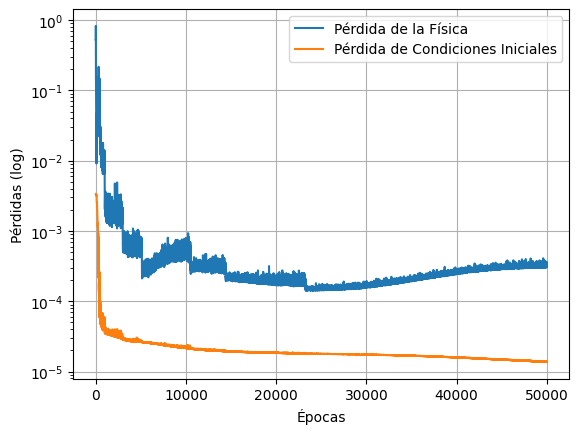

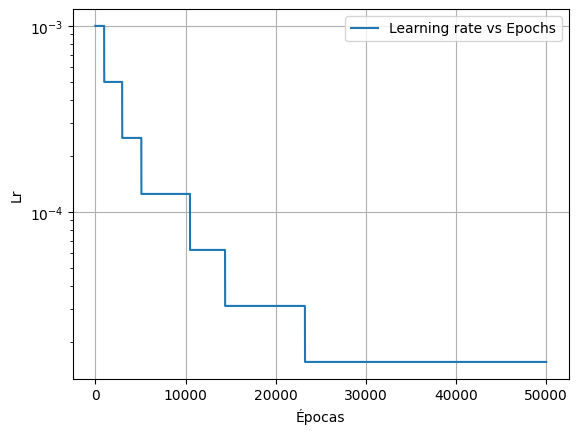


================ REPORTE DE ERROR MAE (ω = 5.50π) ================
Piso 1 -> MAE: 1.605442e-04 m
Piso 2 -> MAE: 3.008986e-04 m
Piso 3 -> MAE: 4.046173e-04 m
Piso 4 -> MAE: 4.580717e-04 m
----------------------------------------------------------------
MAE GLOBAL DEL EDIFICIO: 3.310330e-04 m

Piso 1: MAE = 1.605442e-04 m


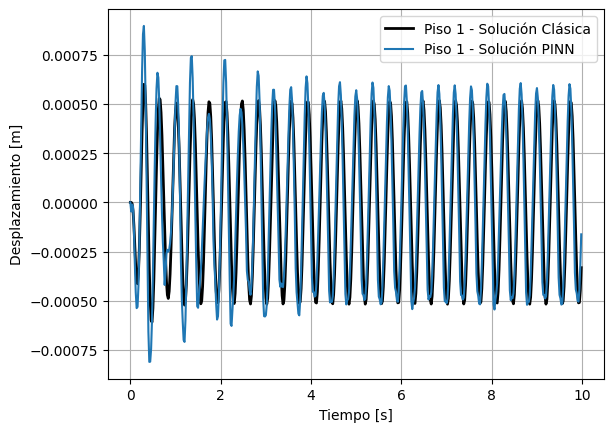

Piso 2: MAE = 3.008986e-04 m


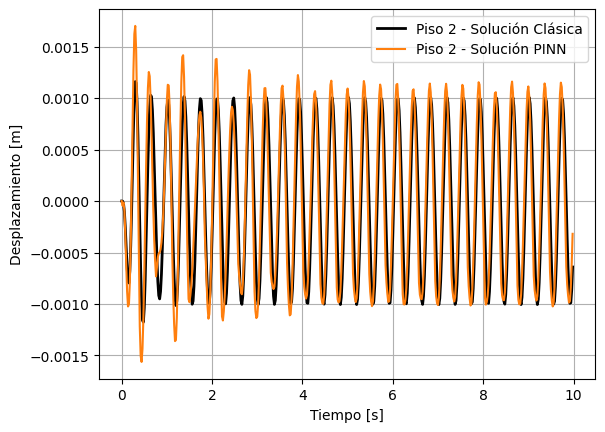

Piso 3: MAE = 4.046173e-04 m


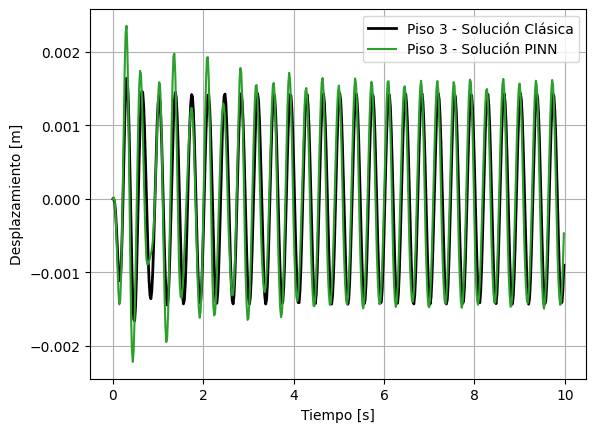

Piso 4: MAE = 4.580717e-04 m


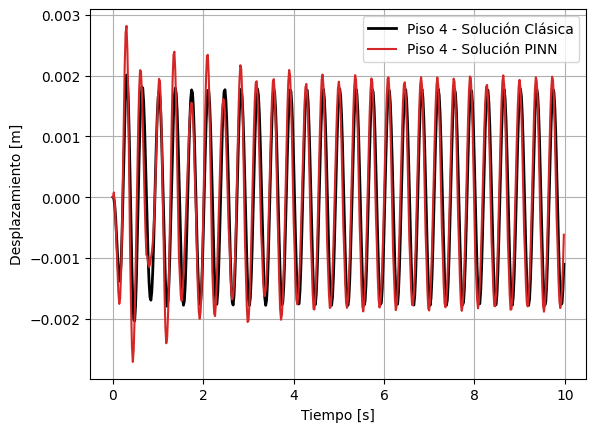

MAE Global: 3.310330e-04 m


In [63]:
# Modelo
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from time import time

class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, is_first=False, omega_0=18.0):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1 / self.linear.in_features
            else:
                bound = np.sqrt(6 / self.linear.in_features) / self.omega_0
            self.linear.weight.uniform_(-bound, bound)
            if self.linear.bias is not None:
                self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

class AutoregressivePINN_SIREN(nn.Module):
    def __init__(self, dim_in, dim_out, hidden_features=128, omega_0=30.0, escala_operacional=1e-3):
        super().__init__()
        self.escala = escala_operacional
        self.net = nn.Sequential(
            SineLayer(dim_in, hidden_features, is_first=True, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            nn.Linear(hidden_features, dim_out)
        )
        with torch.no_grad():
            bound = np.sqrt(6 / hidden_features) / omega_0
            self.net[-1].weight.uniform_(-bound, bound)


    def forward(self, x):
        raw_result = self.net(x)
        return raw_result*self.escala




def generar_matriz_K_torch(N_dof, k_val, device='cpu'):
    """
    Genera la matriz de rigidez K acoplada para un edificio de N pisos en PyTorch.
    """
    # 1. Inicializar una matriz de ceros con el tamaño adecuado
    K = torch.zeros((N_dof, N_dof), dtype=torch.float32, device=device)

    # 2. Llenar la estructura tridiagonal para los pisos intermedios
    for i in range(N_dof - 1):
        K[i, i] = 2 * k_val      # Conectado con el piso de abajo y el de arriba
        K[i, i+1] = -k_val     # Acoplamiento con el piso superior
        K[i+1, i] = -k_val     # Acoplamiento simétrico

    # 3. Ajustar la condición de borde del techo (último piso)
    # El techo no tiene un piso arriba, por lo que su rigidez propia es solo k
    K[N_dof - 1, N_dof - 1] = k_val

    return K


def Generar_Contexto_Operacional(N_dof, t_step_max, rango_omega, m_val=80.0, k_val=400000.0, num_muestras=5000, tiempo_global=10):
    dim_entrada = 3 + 2 * N_dof

    m_vec = torch.tensor([m_val]*N_dof, device="cpu", dtype=torch.float32)
    K_torch = generar_matriz_K_torch(N_dof=N_dof, k_val=k_val, device="cpu")
    C_torch = 0.05 * torch.diag(m_vec) + 0.01 * K_torch

    sobol = torch.quasirandom.SobolEngine(dim_entrada)
    X_raw = sobol.draw(num_muestras)



    X_f = torch.zeros(num_muestras, dim_entrada, device="cpu")

    X_f[:, 1:2] = X_raw[:, 1:2] * t_step_max
    X_f[:, 2:3] = X_raw[:, 2:3] * (rango_omega[1] - rango_omega[0]) + rango_omega[0] # omega

    T_periodo = 2 * np.pi / X_f[:, 2:3] # T = 2π / omega
    t_abs_bruto = X_raw[:, 0:1] * tiempo_global
    X_f[:, 0:1] = torch.remainder(t_abs_bruto, T_periodo)   # Mapeo circular: t_abs siempre estará entre [0, T_periodo]


    # CORRECCIÓN: Rango físico realista. u0 en [-0.005, 0.005] m, v0 en [-0.05, 0.05] m/s
    X_f[:, 3:3+N_dof] = (X_raw[:, 3:3+N_dof] - 0.5) * 0.02
    X_f[:, 3+N_dof:] = (X_raw[:, 3+N_dof:] - 0.5) * 0.2
    X_f.requires_grad_(True)

    return (m_vec, K_torch, C_torch, X_f)


def Entrenar_Red(N_dof, t_step_max, M_vec, K, C, X_f, epochs, omega_red=5, lam_amortiguamiento=1, learning_rate=1e-3, lam_condiciones_iniciales = 1000.0):
    print(f"Utilizando: {device}")
    m_vec = M_vec.to(device)
    K_torch = K.to(device)
    C_torch = C.to(device)
    X_f = X_f.to(device)

    dim_entrada = 3 + 2 * N_dof

    # CORRECCIÓN: Instanciamos la red SIREN (omega_0=30 funciona bien para tu problema)
    model = AutoregressivePINN_SIREN(dim_entrada, N_dof, hidden_features=128, omega_0=omega_red).to(device)

    # optimizer = SOAP(model.parameters(), lr=learning_rate)
    optimizer = SOAP(model.parameters(), lr=1e-3, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=200)
    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    Loss_f_list, Loss_ic_list, LR_list = [], [], []
    T0 = time()
    for epoch in range(1, epochs + 1):

        optimizer.zero_grad()

        t_abs = X_f[:, 0:1]
        t = X_f[:, 1:2]
        omega = X_f[:, 2:3]
        u0_input = X_f[:, 3:3+N_dof]
        v0_input = X_f[:, 3+N_dof:]

        u_f = model(X_f)
        escala = 1e-3

        u_t_list, u_tt_list = [], []
        for i in range(N_dof):
            g_u = torch.autograd.grad(u_f[:, i], X_f, torch.ones_like(u_f[:, i]), create_graph=True)[0]
            u_t_i = g_u[:, 1:2]
            u_t_list.append(u_t_i)
            u_tt_list.append(torch.autograd.grad(u_t_i, X_f, torch.ones_like(u_t_i), create_graph=True)[0][:, 1:2])

        u_t = torch.cat(u_t_list, dim=1)
        u_tt = torch.cat(u_tt_list, dim=1)

        # CORRECCIÓN 1: Tiempo actual (t_abs + t)
        t_current = t_abs + t
        F = torch.zeros_like(u_f)
        F[:, -1:] = -100.0 * torch.sin(omega * t_current)

        # CORRECCIÓN 2: Ecuación diferencial dividida por la masa
        # m_vec es un vector, al dividir aprovechamos el broadcasting tensor de PyTorch
        residual = u_tt + lam_amortiguamiento * (u_t @ C_torch.T) / m_vec + (u_f @ K_torch.T) / m_vec - F / m_vec
        loss_f = torch.mean(residual**2)

        X_ic = X_f.clone()
        X_ic[:, 1:2] = 0.0

        u_pred_0 = model(X_ic)

        u_t_0_list = []
        for i in range(N_dof):
            g_u0 = torch.autograd.grad(u_pred_0[:, i], X_ic, torch.ones_like(u_pred_0[:, i]), create_graph=True)[0]
            u_t_0_list.append(g_u0[:, 1:2])
        u_t_0 = torch.cat(u_t_0_list, dim=1)

        loss_ic = torch.mean((u_pred_0 - u0_input)**2) + torch.mean((u_t_0 - v0_input)**2)

        Loss_f_list.append(loss_f.item())
        Loss_ic_list.append(loss_ic.item())

        # CORRECCIÓN 3: Mayor peso a las condiciones iniciales para que no sean aplastadas
        loss_total = 1.0 * loss_f + lam_condiciones_iniciales * loss_ic

        current_lr = optimizer.param_groups[0]['lr']
        LR_list.append(current_lr)

        loss_total.backward()
        optimizer.step()
        scheduler.step(loss_total)

        if epoch % (epochs//25) == 0 or epoch == 1:
            print(f"Época {epoch}/{epochs} | L_Total: {loss_total.item():.6e} | L_Física: {loss_f.item():.6e} | L_IC: {lam_condiciones_iniciales*loss_ic.item():.6e} | Lr: {current_lr:.6e} | tiempo: {time()-T0:.2f}")

    plt.plot(Loss_f_list, label='Pérdida de la Física')
    plt.plot(Loss_ic_list, label='Pérdida de Condiciones Iniciales')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Pérdidas (log)')
    plt.yscale("log")
    plt.grid()
    plt.savefig(RUTA_PLOTS + "SIREN_SOAPv2_Loss.png", dpi=400, bbox_inches="tight")
    plt.show()

    plt.plot(LR_list, label='Learning rate vs Epochs')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Lr')
    plt.yscale("log")
    plt.grid()
    plt.savefig(RUTA_PLOTS + "SIREN_SOAPv2_Lr.png", dpi=400, bbox_inches="tight")
    plt.show()

    return model

def evaluar_y_cuantificar_pinn(model, N_dof, omega_test, m_val, k_val, tiempo_total=2.0, t_step_max=0.1):
    """
    Evalúa la PINN Autoregresiva en un horizonte largo mediante rolling inference,
    la compara con SciPy (RK45) y calcula el MAE (Mean Absolute Error).

    Argumentos:
    - model: Tu modelo PINN entrenado.
    - N_dof: Número de grados de libertad (pisos).
    - omega_test: Frecuencia paramétrica a evaluar (ej: 5.5 * np.pi).
    - tiempo_total: Tiempo total de la simulación extensa (por defecto 2.0s).
    - t_step_max: El paso delta_t con el que se entrenó la red (por defecto 0.1s).
    """
    # Verificar dispositivo del modelo
    device = next(model.parameters()).device
    model.eval()

    # 1. GENERACIÓN INTERNA DE MATRICES FÍSICAS (Basado en N_dof)


    M_np = np.diag([m_val] * N_dof)
    K_np = generar_matriz_K_torch(N_dof, k_val).numpy()
    C_np = 0.05 * M_np + 0.01 * K_np
    M_inv = np.linalg.inv(M_np)
    # 2. SIMULACIÓN TEMPORAL ENCADENADA (PINN ROLLING INFERENCE)
    pasos_totales = int(tiempo_total // t_step_max)

    historial_tiempo = [0.0]
    historial_desplazamientos = [np.zeros(N_dof)]

    u_actual = torch.zeros(1, N_dof, device=device)
    v_actual = torch.zeros(1, N_dof, device=device)
    t_delta_tensor = torch.tensor([[t_step_max]], device=device)
    omega_tensor = torch.tensor([[omega_test]], device=device)
    T_test = 2 * np.pi / omega_test
    t_acumulado = 0.0

    for paso in range(pasos_totales):



        # Mapear el tiempo de vuelta al primer periodo de forma continua
        t_abs_mapeado = t_acumulado % T_test

        # Pasarle el tiempo mapeado a la red, NO el tiempo acumulado bruto
        t_abs_tensor = torch.tensor([[t_abs_mapeado]], device=device)

        X_step = torch.cat([t_abs_tensor, t_delta_tensor, omega_tensor, u_actual, v_actual], dim=1)
        X_step.requires_grad_(True)

        u_siguiente = model(X_step)

        # Bucle de velocidad con la corrección de retención de grafo
        v_siguiente_list = []
        for i in range(N_dof):
            g_u = torch.autograd.grad(
                u_siguiente[:, i],
                X_step,
                torch.ones_like(u_siguiente[:, i]),
                retain_graph=True
            )[0]
            v_siguiente_list.append(g_u[:, 1:2])
        v_siguiente = torch.cat(v_siguiente_list, dim=1)

        # Actualizar estados para el siguiente paso
        u_actual = u_siguiente.detach()
        v_actual = v_siguiente.detach()

        t_acumulado += t_step_max

        historial_tiempo.append(t_acumulado)
        historial_desplazamientos.append(u_actual.cpu().numpy()[0])

    u_pinn = np.array(historial_desplazamientos).T # Dimensión: (N_dof, pasos + 1)
    t_eval_pinn = np.array(historial_tiempo)

    # 3. SOLVER CLÁSICO (SciPy RK45) EVALUADO EN LOS MISMOS PUNTOS EXACTOS
    def sistema_NDOF(t, y):
        u = y[:N_dof]
        v = y[N_dof:]
        F = np.zeros(N_dof)
        F[-1] = -100.0 * np.sin(omega_test * t) # Fuerza en el techo
        dudt = v
        dvdt = M_inv @ (F - C_np @ v - K_np @ u)
        return np.concatenate([dudt, dvdt])

    y0 = np.zeros(2 * N_dof)
    solucion_exacta = solve_ivp(
        sistema_NDOF,
        (0.0, tiempo_total),
        y0,
        t_eval=t_eval_pinn, # Forzamos alineación temporal perfecta para restar matrices
        method='RK45'
    )
    u_clasico = solucion_exacta.y[:N_dof] # Dimensión: (N_dof, pasos + 1)

    # 4. CÁLCULO CUANTITATIVO DEL MAE (Mean Absolute Error)
    print(f"\n================ REPORTE DE ERROR MAE (ω = {omega_test/np.pi:.2f}π) ================")
    maes_por_piso = []

    for i in range(N_dof):
        # MAE = Mean(| u_real - u_pred |)
        mae_piso = np.mean(np.abs(u_clasico[i] - u_pinn[i]))
        maes_por_piso.append(mae_piso)
        print(f"Piso {i+1} -> MAE: {mae_piso:.6e} m")

    mae_global = np.mean(np.abs(u_clasico - u_pinn))
    print(f"----------------------------------------------------------------")
    print(f"MAE GLOBAL DEL EDIFICIO: {mae_global:.6e} m")
    print("================================================================\n")

    # Retorna los tiempos, la solución clásica, la solución pinn y el diccionario de métricas
    return t_eval_pinn, u_clasico, u_pinn, {"maes_pisos": maes_por_piso, "mae_global": mae_global}



print("MODELO SIREN")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_dof = 4
t_step_max = 0.02
rango_omega = (3 * np.pi, 7 * np.pi)    #Parámetro operacional variable
m_val, k_val = 80.0, 400000.0             # 80 tons y 40.000 kN/m^2
N_epochs = 50000
omega_red = 18.261291103470565
Lr = 0.00020969512321501158
Lam_IC = 504.53183753538866

condiciones = Generar_Contexto_Operacional(n_dof, t_step_max, rango_omega, m_val, k_val, num_muestras=10000)
model = Entrenar_Red(n_dof, t_step_max, *condiciones, epochs=N_epochs, omega_red=omega_red, lam_amortiguamiento=1, learning_rate=Lr, lam_condiciones_iniciales=Lam_IC)

time, u_clasico, u_pinn, metrics = evaluar_y_cuantificar_pinn(model, n_dof, omega_test=5.5 * np.pi, m_val=m_val, k_val=k_val, tiempo_total=10, t_step_max=t_step_max)

for piso, mae in enumerate(metrics["maes_pisos"]):
    print(f"Piso {piso+1}: MAE = {mae:.6e} m")
    plt.plot(time, u_clasico[piso], label=f'Piso {piso+1} - Solución Clásica', color='black', linewidth=2)
    plt.plot(time, u_pinn[piso], label=f'Piso {piso+1} - Solución PINN', color=f'C{piso}', linewidth=1.5)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Desplazamiento [m]')
    plt.grid()
    plt.legend()
    plt.savefig(RUTA_PLOTS + f"SIREN_SOAPv2_piso{piso+1}.png", dpi=400, bbox_inches="tight")
    plt.show()
print(f"MAE Global: {metrics['mae_global']:.6e} m")

In [64]:
# Guarda solo los parámetros matemáticos del modelo
ruta_guardado = "D:/Documentos/USM/Proyecto fis computacional/modelo_siren_4dof.pth"
torch.save(model.state_dict(), ruta_guardado)
print(f"Modelo guardado exitosamente en {ruta_guardado}")

Modelo guardado exitosamente en D:/Documentos/USM/Proyecto fis computacional/modelo_siren_4dof.pth


AutoregressivePINN_SIREN(
  (net): Sequential(
    (0): SineLayer(
      (linear): Linear(in_features=11, out_features=128, bias=True)
    )
    (1): SineLayer(
      (linear): Linear(in_features=128, out_features=128, bias=True)
    )
    (2): SineLayer(
      (linear): Linear(in_features=128, out_features=128, bias=True)
    )
    (3): SineLayer(
      (linear): Linear(in_features=128, out_features=128, bias=True)
    )
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)

================ REPORTE DE ERROR MAE (ω = 6.45π) ================
Piso 1 -> MAE: 2.876700e-04 m
Piso 2 -> MAE: 5.389508e-04 m
Piso 3 -> MAE: 7.253674e-04 m
Piso 4 -> MAE: 8.246280e-04 m
----------------------------------------------------------------
MAE GLOBAL DEL EDIFICIO: 5.941540e-04 m

 Tiempo de evaluación de SciPy: 0.01140 segundos
 Tiempo de evaluación de PINN: 0.41865 segundos
Piso 1: MAE = 2.876700e-04 m


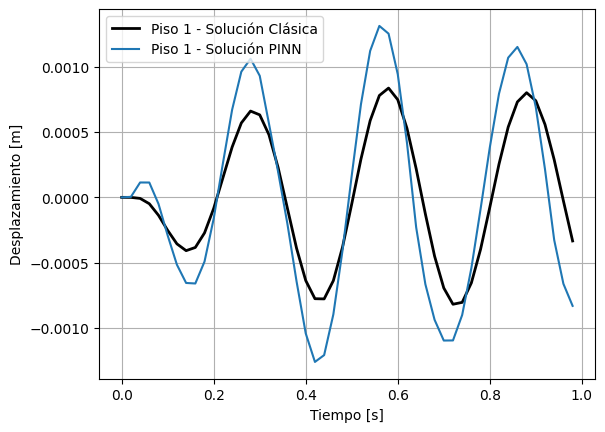

Piso 2: MAE = 5.389508e-04 m


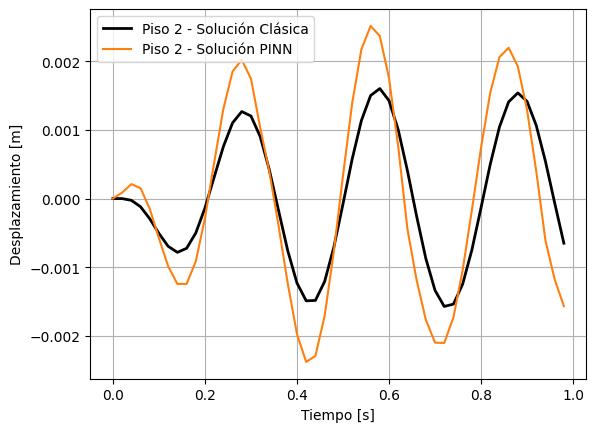

Piso 3: MAE = 7.253674e-04 m


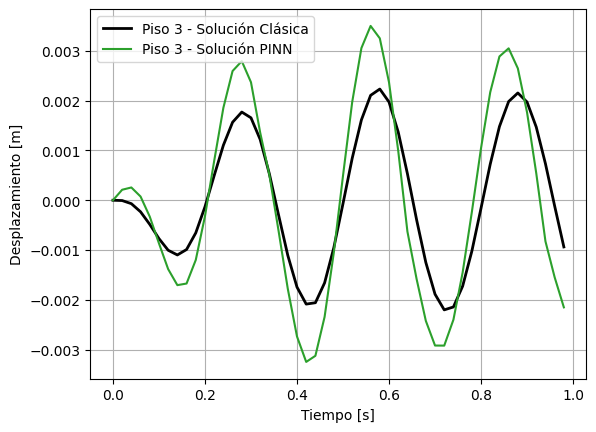

Piso 4: MAE = 8.246280e-04 m


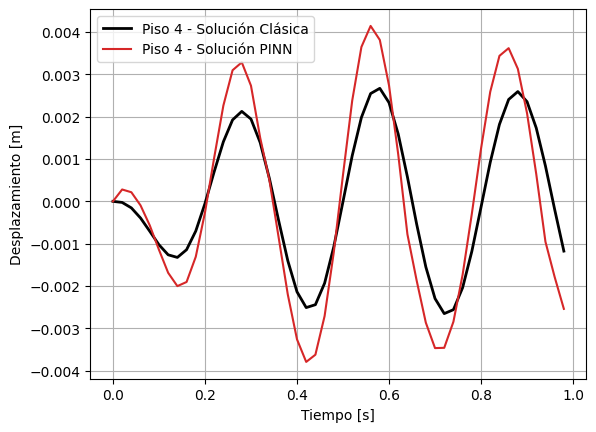

MAE Global: 5.941540e-04 m

================ REPORTE DE ERROR MAE (ω = 6.45π) ================
Piso 1 -> MAE: 2.926284e-04 m
Piso 2 -> MAE: 5.492823e-04 m
Piso 3 -> MAE: 7.449059e-04 m
Piso 4 -> MAE: 8.520172e-04 m
----------------------------------------------------------------
MAE GLOBAL DEL EDIFICIO: 6.097084e-04 m

 Tiempo de evaluación de SciPy: 0.24995 segundos
 Tiempo de evaluación de PINN: 3.67273 segundos
Piso 1: MAE = 2.926284e-04 m


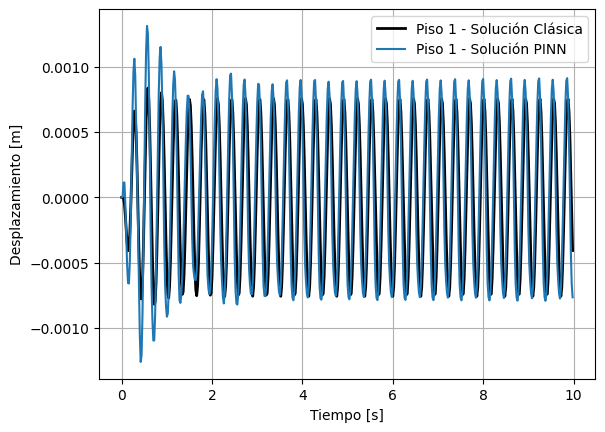

Piso 2: MAE = 5.492823e-04 m


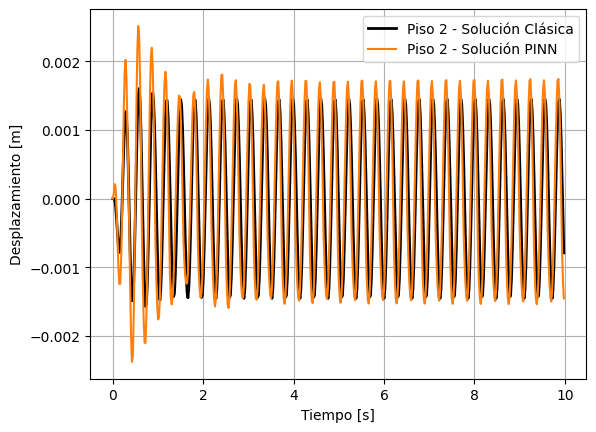

Piso 3: MAE = 7.449059e-04 m


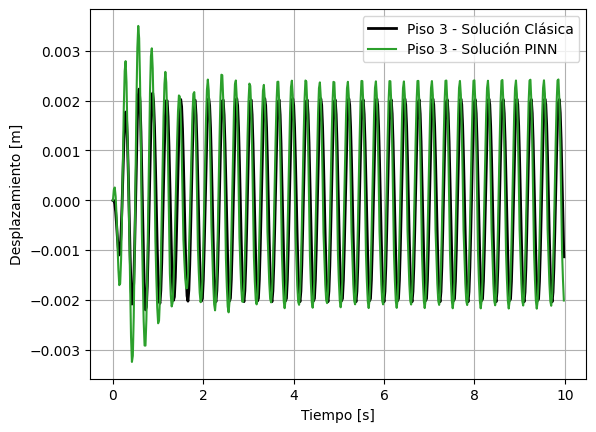

Piso 4: MAE = 8.520172e-04 m


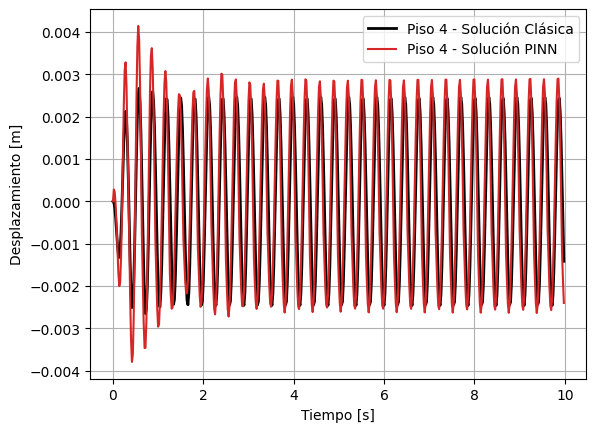

MAE Global: 6.097084e-04 m


In [85]:
# Hagamos que el modelo Sweepee para varios Omegas entre 3 y 7:
from time import time

def evaluar_y_cuantificar_pinn(model, N_dof, omega_test, m_val, k_val, tiempo_total=2.0, t_step_max=0.1):
    """
    Evalúa la PINN Autoregresiva en un horizonte largo mediante rolling inference,
    la compara con SciPy (RK45) y calcula el MAE (Mean Absolute Error).

    Argumentos:
    - model: Tu modelo PINN entrenado.
    - N_dof: Número de grados de libertad (pisos).
    - omega_test: Frecuencia paramétrica a evaluar (ej: 5.5 * np.pi).
    - tiempo_total: Tiempo total de la simulación extensa (por defecto 2.0s).
    - t_step_max: El paso delta_t con el que se entrenó la red (por defecto 0.1s).
    """
    # Verificar dispositivo del modelo
    device = next(model.parameters()).device
    model.eval()

    # 1. GENERACIÓN INTERNA DE MATRICES FÍSICAS (Basado en N_dof)


    M_np = np.diag([m_val] * N_dof)
    K_np = generar_matriz_K_torch(N_dof, k_val).numpy()
    C_np = 0.05 * M_np + 0.01 * K_np
    M_inv = np.linalg.inv(M_np)
    # 2. SIMULACIÓN TEMPORAL ENCADENADA (PINN ROLLING INFERENCE)
    time_0 = time()
    pasos_totales = int(tiempo_total // t_step_max)

    historial_tiempo = [0.0]
    historial_desplazamientos = [np.zeros(N_dof)]

    u_actual = torch.zeros(1, N_dof, device=device)
    v_actual = torch.zeros(1, N_dof, device=device)
    t_delta_tensor = torch.tensor([[t_step_max]], device=device)
    omega_tensor = torch.tensor([[omega_test]], device=device)
    T_test = 2 * np.pi / omega_test
    t_acumulado = 0.0

    for paso in range(pasos_totales):



        # Mapear el tiempo de vuelta al primer periodo de forma continua
        t_abs_mapeado = t_acumulado % T_test

        # Pasarle el tiempo mapeado a la red, NO el tiempo acumulado bruto
        t_abs_tensor = torch.tensor([[t_abs_mapeado]], device=device)

        X_step = torch.cat([t_abs_tensor, t_delta_tensor, omega_tensor, u_actual, v_actual], dim=1)
        X_step.requires_grad_(True)

        u_siguiente = model(X_step)

        # Bucle de velocidad con la corrección de retención de grafo
        v_siguiente_list = []
        for i in range(N_dof):
            g_u = torch.autograd.grad(
                u_siguiente[:, i],
                X_step,
                torch.ones_like(u_siguiente[:, i]),
                retain_graph=True
            )[0]
            v_siguiente_list.append(g_u[:, 1:2])
        v_siguiente = torch.cat(v_siguiente_list, dim=1)

        # Actualizar estados para el siguiente paso
        u_actual = u_siguiente.detach()
        v_actual = v_siguiente.detach()

        t_acumulado += t_step_max

        historial_tiempo.append(t_acumulado)
        historial_desplazamientos.append(u_actual.cpu().numpy()[0])

    u_pinn = np.array(historial_desplazamientos).T # Dimensión: (N_dof, pasos + 1)
    t_eval_pinn = np.array(historial_tiempo)
    tiempo_evaluacion_pinn = time() - time_0

    time_1 = time()
    # 3. SOLVER CLÁSICO (SciPy RK45) EVALUADO EN LOS MISMOS PUNTOS EXACTOS
    def sistema_NDOF(t, y):
        u = y[:N_dof]
        v = y[N_dof:]
        F = np.zeros(N_dof)
        F[-1] = -100.0 * np.sin(omega_test * t) # Fuerza en el techo
        dudt = v
        dvdt = M_inv @ (F - C_np @ v - K_np @ u)
        return np.concatenate([dudt, dvdt])

    y0 = np.zeros(2 * N_dof)
    solucion_exacta = solve_ivp(
        sistema_NDOF,
        (0.0, tiempo_total),
        y0,
        t_eval=t_eval_pinn, # Forzamos alineación temporal perfecta para restar matrices
        method='RK45'
    )
    u_clasico = solucion_exacta.y[:N_dof] # Dimensión: (N_dof, pasos + 1)
    time_2 = time()
    tiempo_evaluacion_clasico = time_2 - time_1

    # 4. CÁLCULO CUANTITATIVO DEL MAE (Mean Absolute Error)
    print(f"\n================ REPORTE DE ERROR MAE (ω = {omega_test/np.pi:.2f}π) ================")
    maes_por_piso = []

    for i in range(N_dof):
        # MAE = Mean(| u_real - u_pred |)
        mae_piso = np.mean(np.abs(u_clasico[i] - u_pinn[i]))
        maes_por_piso.append(mae_piso)
        print(f"Piso {i+1} -> MAE: {mae_piso:.6e} m")

    mae_global = np.mean(np.abs(u_clasico - u_pinn))
    print(f"----------------------------------------------------------------")
    print(f"MAE GLOBAL DEL EDIFICIO: {mae_global:.6e} m")
    print("================================================================\n")

    # Retorna los tiempos, la solución clásica, la solución pinn y el diccionario de métricas
    return t_eval_pinn, u_clasico, u_pinn, {"maes_pisos": maes_por_piso, "mae_global": mae_global}, (tiempo_evaluacion_clasico, tiempo_evaluacion_pinn)

print(model)

save_plots=False
omega_hz = 6.45
dt = 0.02
n_dof = 4
tiempos_pinn=[]
tiempos_solve_ivp=[]
for t in [1, 10]:
    tiempo, u_clasico, u_pinn, metrics, (tiempo_evaluacion_clasico, tiempo_evaluacion_pinn) = evaluar_y_cuantificar_pinn(model, n_dof, omega_test=omega_hz * np.pi, m_val=m_val, k_val=k_val, tiempo_total=t, t_step_max=dt)
    tiempos_pinn.append(tiempo_evaluacion_pinn)
    tiempos_solve_ivp.append(tiempo_evaluacion_clasico)
    print(f" Tiempo de evaluación de SciPy: {tiempo_evaluacion_clasico:.5f} segundos")
    print(f" Tiempo de evaluación de PINN: {tiempo_evaluacion_pinn:.5f} segundos")
    for piso, mae in enumerate(metrics["maes_pisos"]):
        print(f"Piso {piso+1}: MAE = {mae:.6e} m")
        plt.plot(tiempo, u_clasico[piso], label=f'Piso {piso+1} - Solución Clásica', color='black', linewidth=2)
        plt.plot(tiempo, u_pinn[piso], label=f'Piso {piso+1} - Solución PINN', color=f'C{piso}', linewidth=1.5)
        plt.xlabel('Tiempo [s]')
        plt.ylabel('Desplazamiento [m]')
        plt.grid()
        plt.legend()
        if save_plots:
            plt.savefig(RUTA_PLOTS + f"/test finales/MODELO FINAL_time{t}_seg_freq{omega_hz}_{piso+1}.png", dpi=400, bbox_inches="tight")
        plt.show()
    print(f"MAE Global: {metrics['mae_global']:.6e} m")

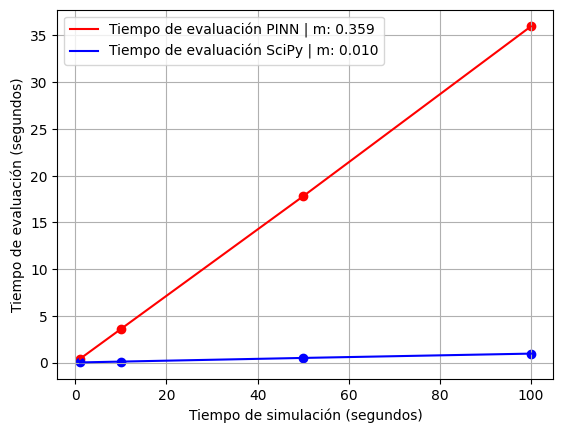

D:/Documentos/USM/Proyecto fis computacional/Plots


In [79]:
tiempos = [1, 10, 50, 100]
m_pinn, b_pinn = np.polyfit(tiempos, tiempos_pinn, 1)
m_solve_ivp, b_solve_ivp = np.polyfit(tiempos, tiempos_solve_ivp, 1)
ajuste_pinn = m_pinn * np.array(tiempos) + b_pinn
ajuste_solve_ivp = m_solve_ivp * np.array(tiempos) + b_solve_ivp

plt.plot(tiempos, tiempos_pinn, label=f"Tiempo de evaluación PINN | m: {m_pinn:.3f}", color="red")
plt.plot(tiempos, tiempos_solve_ivp, label=f"Tiempo de evaluación SciPy | m: {m_solve_ivp:.3f}", color="blue")
plt.scatter([1, 10, 50, 100], tiempos_pinn, color="red")
plt.scatter([1, 10, 50, 100], tiempos_solve_ivp, color="blue")
plt.grid()
plt.xlabel("Tiempo de simulación (segundos)")
plt.ylabel("Tiempo de evaluación (segundos)")
plt.legend()
plt.savefig(RUTA_PLOTS + "/tiempos_evaluacion.png", dpi=400, bbox_inches="tight")
plt.show()

print(RUTA_PLOTS)